# Prédiction de l'attrition RH - TechNova Partners
### Notebook 01 - Exploration des données et préparation des features

**Auteure :** Angèle GOMIS -- **Formation :** AI Engineer -- Projet 4 -- **Date :** septembre 2026

---

## Contexte

TechNova Partners, ESN spécialisée en transformation digitale, fait face à un turnover élevé. Le directeur du SIRH veut savoir ce qui distingue réellement les collaborateurs qui partent de ceux qui restent, avant d'envisager un dispositif de détection. Je dispose de trois extraits, un par système d'information : SIRH, évaluations annuelles, sondage interne (qui porte la cible).

## Organisation du projet

| Notebook | Étapes de l'énoncé | Sortie |
|---|---|---|
| **01 - Exploration et features** (ce notebook) | Étape 1 : analyse exploratoire. Étape 2 : feature engineering, construction de `X` et `y` | `data/interim/consolide.parquet`, `data/processed/X.parquet`, `data/processed/y.parquet` |
| 02 - Modélisation | Découpage 60 / 20 / 20. Étape 3 : modèles de référence. Étape 4 : déséquilibre des classes et seuil. Étape 5 : réglage fin des hyperparamètres. Confirmation finale sur le test | `models/modele_final.joblib`, `models/metadonnees_modele.json` |
| 03 - Interprétabilité | Étape 5 : importance globale et locale des features (permutation, SHAP) | `reports/facteurs_actions.csv` |

## Objectifs de ce notebook

**Étape 1 - Analyse exploratoire**
1. Charger et décrire les trois sources, avec des statistiques descriptives sur chacune ;
2. Nettoyer les colonnes avec `.apply()` et vérifier la cohérence métier ;
3. Identifier les clés de jointure et construire le DataFrame central ;
4. Faire ressortir, par des statistiques descriptives et des graphiques adaptés au type de variables, les différences entre partants et restants.

**Étape 2 - Préparation des features**
1. Créer des features métier à partir des données existantes ;
2. Choisir un encodage par variable qualitative, selon son sens métier ;
3. Éliminer les fortes corrélations linéaires (matrice de Pearson) et observer les relations non linéaires (pairplot, matrice de Spearman) ;
4. Produire `X` (features prêtes pour `fit()`) et `y` (cible), par des fonctions réutilisables.

**Aucun apprentissage n'a lieu dans ce notebook.** Les transformations appliquées ici sont des correspondances fixes, qui n'apprennent rien des données. Tout ce qui s'ajuste sur les données (mise à l'échelle, modèles) sera ajusté à l'étape 3, sur le seul jeu d'entraînement (60 % des collaborateurs), pour éviter toute fuite d'information vers les jeux de validation et de test.

## Relancer ce notebook

L'environnement du projet est géré avec **uv** (voir le `README.md` à la racine du projet). Les commandes se lancent depuis la **racine du projet** :

```bat
cd /d "C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh"
uv sync
uv run jupyter lab
```

Exécution complète sans ouvrir l'interface, les sorties étant réécrites dans le fichier :

```bat
uv run jupyter nbconvert --to notebook --execute --inplace notebooks\01_exploration_features_final_0210.ipynb
```

L'ordre d'exécution est imposé : 01, puis 02, puis 03. Chaque notebook relit les fichiers produits par le précédent.

---

---
# Étape 1 - Analyse exploratoire

---
## 1. Chargement et dictionnaire des variables

In [1]:
# --- Bibliotheques ---
from __future__ import annotations

from collections import defaultdict
from collections.abc import Mapping, Sequence
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.utils.validation import check_X_y

from src import config

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

# Palette commune a tout le projet : bleu pour les restes, rouge pour les departs
PALETTE_CIBLE = {
    config.MODALITE_RESTE: config.COULEUR_RESTE,
    config.MODALITE_DEPART: config.COULEUR_DEPART,
}

for dossier in (
    config.DOSSIER_DONNEES_INTERMEDIAIRES,
    config.DOSSIER_DONNEES_TRAITEES,
    config.DOSSIER_RAPPORTS,
):
    dossier.mkdir(parents=True, exist_ok=True)

print(f"Racine du projet : {config.RACINE_PROJET}")

Racine du projet : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh


In [2]:
df_sirh = pd.read_csv(config.FICHIER_SIRH, encoding=config.ENCODAGE_SOURCE)
df_eval = pd.read_csv(config.FICHIER_EVAL, encoding=config.ENCODAGE_SOURCE)
df_sondage = pd.read_csv(config.FICHIER_SONDAGE, encoding=config.ENCODAGE_SOURCE)

for nom, d in [("SIRH", df_sirh), ("Evaluations", df_eval), ("Sondage", df_sondage)]:
    print(f"{nom:<12} {d.shape[0]} lignes x {d.shape[1]} colonnes")

SIRH         1470 lignes x 12 colonnes
Evaluations  1470 lignes x 10 colonnes
Sondage      1470 lignes x 12 colonnes


In [3]:
# --- Dictionnaire des variables : nom, signification, type attendu, unite, source ---
dictionnaire_variables = pd.DataFrame(
    [
        # SIRH
        {
            "nom": "id_employee",
            "signification": "Identifiant unique du collaborateur",
            "type_attendu": "int64",
            "unite": "identifiant",
            "source": "SIRH",
        },
        {
            "nom": "age",
            "signification": "Age du collaborateur",
            "type_attendu": "int64",
            "unite": "annees",
            "source": "SIRH",
        },
        {
            "nom": "genre",
            "signification": "Genre declare du collaborateur",
            "type_attendu": "object",
            "unite": "categorie (F/M)",
            "source": "SIRH",
        },
        {
            "nom": "revenu_mensuel",
            "signification": "Remuneration mensuelle brute",
            "type_attendu": "int64",
            "unite": "euros",
            "source": "SIRH",
        },
        {
            "nom": "statut_marital",
            "signification": "Situation familiale declaree",
            "type_attendu": "object",
            "unite": "categorie",
            "source": "SIRH",
        },
        {
            "nom": "departement",
            "signification": "Departement de rattachement",
            "type_attendu": "object",
            "unite": "categorie",
            "source": "SIRH",
        },
        {
            "nom": "poste",
            "signification": "Intitule de poste occupe",
            "type_attendu": "object",
            "unite": "categorie",
            "source": "SIRH",
        },
        {
            "nom": "nombre_experiences_precedentes",
            "signification": "Nombre d'employeurs precedents",
            "type_attendu": "int64",
            "unite": "nombre",
            "source": "SIRH",
        },
        {
            "nom": "nombre_heures_travailless",
            "signification": "Duree hebdomadaire de travail contractuelle (intitule source, faute incluse)",
            "type_attendu": "int64",
            "unite": "heures/semaine",
            "source": "SIRH",
        },
        {
            "nom": "annee_experience_totale",
            "signification": "Experience professionnelle totale, tous employeurs confondus",
            "type_attendu": "int64",
            "unite": "annees",
            "source": "SIRH",
        },
        {
            "nom": "annees_dans_l_entreprise",
            "signification": "Anciennete dans l'entreprise actuelle",
            "type_attendu": "int64",
            "unite": "annees",
            "source": "SIRH",
        },
        {
            "nom": "annees_dans_le_poste_actuel",
            "signification": "Anciennete sur le poste actuel",
            "type_attendu": "int64",
            "unite": "annees",
            "source": "SIRH",
        },
        # Evaluations
        {
            "nom": "eval_number",
            "signification": "Identifiant de jointure vers le SIRH, format E_<id>",
            "type_attendu": "object -> int64",
            "unite": "identifiant",
            "source": "Evaluations",
        },
        {
            "nom": "satisfaction_employee_environnement",
            "signification": "Satisfaction declaree sur l'environnement de travail",
            "type_attendu": "int64",
            "unite": "echelle 1-4 (a clarifier)",
            "source": "Evaluations",
        },
        {
            "nom": "satisfaction_employee_nature_travail",
            "signification": "Satisfaction declaree sur la nature des missions",
            "type_attendu": "int64",
            "unite": "echelle 1-4 (a clarifier)",
            "source": "Evaluations",
        },
        {
            "nom": "satisfaction_employee_equipe",
            "signification": "Satisfaction declaree sur les relations d'equipe",
            "type_attendu": "int64",
            "unite": "echelle 1-4 (a clarifier)",
            "source": "Evaluations",
        },
        {
            "nom": "satisfaction_employee_equilibre_pro_perso",
            "signification": "Satisfaction declaree sur l'equilibre vie professionnelle / vie personnelle",
            "type_attendu": "int64",
            "unite": "echelle 1-4 (a clarifier)",
            "source": "Evaluations",
        },
        {
            "nom": "note_evaluation_precedente",
            "signification": "Note de la precedente evaluation annuelle",
            "type_attendu": "int64",
            "unite": "echelle 1-4 (a clarifier)",
            "source": "Evaluations",
        },
        {
            "nom": "note_evaluation_actuelle",
            "signification": "Note de l'evaluation annuelle en cours",
            "type_attendu": "int64",
            "unite": "echelle (a clarifier)",
            "source": "Evaluations",
        },
        {
            "nom": "niveau_hierarchique_poste",
            "signification": "Niveau hierarchique du poste occupe",
            "type_attendu": "int64",
            "unite": "echelle 1-5 (a clarifier)",
            "source": "Evaluations",
        },
        {
            "nom": "heure_supplementaires",
            "signification": "Le collaborateur effectue-t-il des heures supplementaires",
            "type_attendu": "object",
            "unite": "categorie (Oui/Non)",
            "source": "Evaluations",
        },
        {
            "nom": "augementation_salaire_precedente",
            "signification": "Taux d'augmentation de la derniere revalorisation salariale (intitule source, faute incluse)",
            "type_attendu": "object -> int64",
            "unite": "pourcentage",
            "source": "Evaluations",
        },
        # Sondage
        {
            "nom": "code_sondage",
            "signification": "Identifiant de jointure vers le SIRH",
            "type_attendu": "int64",
            "unite": "identifiant",
            "source": "Sondage",
        },
        {
            "nom": "a_quitte_l_entreprise",
            "signification": "Le collaborateur a-t-il quitte l'entreprise (cible)",
            "type_attendu": "object",
            "unite": "categorie (Oui/Non)",
            "source": "Sondage",
        },
        {
            "nom": "nombre_participation_pee",
            "signification": "Nombre de participations au plan d'epargne entreprise",
            "type_attendu": "int64",
            "unite": "nombre",
            "source": "Sondage",
        },
        {
            "nom": "nb_formations_suivies",
            "signification": "Nombre de formations suivies sur la derniere periode",
            "type_attendu": "int64",
            "unite": "nombre",
            "source": "Sondage",
        },
        {
            "nom": "nombre_employee_sous_responsabilite",
            "signification": "Nombre de collaborateurs encadres",
            "type_attendu": "int64",
            "unite": "nombre",
            "source": "Sondage",
        },
        {
            "nom": "distance_domicile_travail",
            "signification": "Distance entre le domicile et le lieu de travail",
            "type_attendu": "int64",
            "unite": "kilometres",
            "source": "Sondage",
        },
        {
            "nom": "niveau_education",
            "signification": "Niveau d'etudes atteint",
            "type_attendu": "int64",
            "unite": "echelle 1-5 (a clarifier)",
            "source": "Sondage",
        },
        {
            "nom": "domaine_etude",
            "signification": "Domaine d'etudes suivi",
            "type_attendu": "object",
            "unite": "categorie",
            "source": "Sondage",
        },
        {
            "nom": "ayant_enfants",
            "signification": "Le collaborateur a-t-il des enfants a charge",
            "type_attendu": "object",
            "unite": "categorie",
            "source": "Sondage",
        },
        {
            "nom": "frequence_deplacement",
            "signification": "Frequence des deplacements professionnels",
            "type_attendu": "object",
            "unite": "categorie ordonnee",
            "source": "Sondage",
        },
        {
            "nom": "annees_depuis_la_derniere_promotion",
            "signification": "Temps ecoule depuis la derniere promotion",
            "type_attendu": "int64",
            "unite": "annees",
            "source": "Sondage",
        },
        {
            "nom": "annes_sous_responsable_actuel",
            "signification": "Temps passe sous le responsable actuel (intitule source, faute incluse)",
            "type_attendu": "int64",
            "unite": "annees",
            "source": "Sondage",
        },
    ]
)
display(dictionnaire_variables)

,nom,signification,type_attendu,unite,source
0,id_employee,Identifiant unique du collaborateur,int64,identifiant,SIRH
1,age,Age du collaborateur,int64,annees,SIRH
2,genre,Genre declare du collaborateur,object,categorie (F/M),SIRH
3,revenu_mensuel,Remuneration mensuelle brute,int64,euros,SIRH
4,statut_marital,Situation familiale declaree,object,categorie,SIRH
5,departement,Departement de rattachement,object,categorie,SIRH
6,poste,Intitule de poste occupe,object,categorie,SIRH
7,nombre_experiences_precedentes,Nombre d'employeurs precedents,int64,nombre,SIRH
8,nombre_heures_travailless,Duree hebdomadaire de travail contractuelle (i...,int64,heures/semaine,SIRH
9,annee_experience_totale,"Experience professionnelle totale, tous employ...",int64,annees,SIRH


**Point clé de l'étape.** 
 Trois colonnes portent des fautes de frappe dans la source (`nombre_heures_travailless`, `augementation_salaire_precedente`, `annes_sous_responsable_actuel`) : je les conserve telles quelles, une correction silencieuse romprait la traçabilité avec les fichiers sources.

---
## 2. Contrôle qualité par source, avant jointure

**Question.** Chaque extrait est-il complet, cohérent avec son type attendu, et sans anomalie qui lui soit propre ?

 Une fois les trois sources fusionnées, l'origine d'une anomalie devient indéterminable : un doublon ou une valeur aberrante dans le SIRH ne se distingue plus d'une anomalie introduite par la jointure. Je contrôle donc chaque source isolément : dimensions, types, doublons, manquants, cardinalité des qualitatives, statistiques des quantitatives, bornes aberrantes.

In [4]:
def controle_qualite(nom: str, d: pd.DataFrame, cle: str) -> None:
    print(f"=== {nom} ===")
    print(f"Dimensions : {d.shape[0]} lignes x {d.shape[1]} colonnes")
    print(f"Doublons de lignes : {d.duplicated().sum()}")
    print(f"Doublons d'identifiant ({cle}) : {d[cle].duplicated().sum()}")
    manquants = d.isna().mean().mul(100).round(2)
    print(f"Taux de manquants max : {manquants.max()}% (colonne {manquants.idxmax()})")
    print("Types pandas :")
    print(d.dtypes)
    print()


controle_qualite("SIRH", df_sirh, "id_employee")
controle_qualite("Evaluations", df_eval, "eval_number")
controle_qualite("Sondage", df_sondage, "code_sondage")

=== SIRH ===
Dimensions : 1470 lignes x 12 colonnes
Doublons de lignes : 0
Doublons d'identifiant (id_employee) : 0
Taux de manquants max : 0.0% (colonne id_employee)
Types pandas :
id_employee                       int64
age                               int64
genre                               str
revenu_mensuel                    int64
statut_marital                      str
departement                         str
poste                               str
nombre_experiences_precedentes    int64
nombre_heures_travailless         int64
annee_experience_totale           int64
annees_dans_l_entreprise          int64
annees_dans_le_poste_actuel       int64
dtype: object

=== Evaluations ===
Dimensions : 1470 lignes x 10 colonnes
Doublons de lignes : 0
Doublons d'identifiant (eval_number) : 0
Taux de manquants max : 0.0% (colonne satisfaction_employee_environnement)
Types pandas :
satisfaction_employee_environnement          int64
note_evaluation_precedente                   int64
niveau_h

**Point clé de l'étape.** Aucune des trois sources ne contient de ligne dupliquée ni d'identifiant dupliqué : chaque extrait porte exactement 1 470 collaborateurs distincts. Les types pandas correspondent au dictionnaire du point 1, à l'exception attendue de `eval_number` (texte, à convertir) et de `augementation_salaire_precedente` (texte avec signe pourcentage, à convertir) -- traités au point 3.

In [5]:
# Cardinalite des qualitatives, avec detection de modalites proches (casse, espaces, accents)
for nom, d in [("SIRH", df_sirh), ("Evaluations", df_eval), ("Sondage", df_sondage)]:
    for col in d.select_dtypes("object").columns:
        modalites = d[col].unique().tolist()
        normalisees = defaultdict(list)
        for m in modalites:
            normalisees[m.strip().lower()].append(m)
        collisions = {k: v for k, v in normalisees.items() if len(v) > 1}
        print(f"{nom:<12} {col:<35} {len(modalites):>2} modalites : {modalites}")
        if collisions:
            print(f"{'':<12} {'':<35} modalites proches detectees : {collisions}")

SIRH         genre                                2 modalites : ['F', 'M']
SIRH         statut_marital                       3 modalites : ['Célibataire', 'Marié(e)', 'Divorcé(e)']
SIRH         departement                          3 modalites : ['Commercial', 'Consulting', 'Ressources Humaines']
SIRH         poste                                9 modalites : ['Cadre Commercial', 'Assistant de Direction', 'Consultant', 'Tech Lead', 'Manager', 'Senior Manager', 'Représentant Commercial', 'Directeur Technique', 'Ressources Humaines']
Evaluations  eval_number                         1470 modalites : ['E_1', 'E_2', 'E_4', 'E_5', 'E_7', 'E_8', 'E_10', 'E_11', 'E_12', 'E_13', 'E_14', 'E_15', 'E_16', 'E_18', 'E_19', 'E_20', 'E_21', 'E_22', 'E_23', 'E_24', 'E_26', 'E_27', 'E_28', 'E_30', 'E_31', 'E_32', 'E_33', 'E_35', 'E_36', 'E_38', 'E_39', 'E_40', 'E_41', 'E_42', 'E_45', 'E_46', 'E_47', 'E_49', 'E_51', 'E_52', 'E_53', 'E_54', 'E_55', 'E_56', 'E_57', 'E_58', 'E_60', 'E_61', 'E_62', 'E_63', 'E

C:\Users\Windows 11\AppData\Local\Temp\ipykernel_26824\1682158896.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in d.select_dtypes("object").columns:
C:\Users\Windows 11\AppData\Local\Temp\ipykernel_26824\1682158896.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide

**Point clé de l'étape.** Aucune collision après normalisation de la casse, des espaces ou des accents : les modalités qualitatives sont propres, aucun regroupement de saisie n'est nécessaire.

In [6]:
display(df_sirh.describe().round(2))
display(df_eval.describe().round(2))
display(df_sondage.describe().round(2))

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00
mean,1024.87,36.92,6502.93,2.69,80.0,11.28,7.01,4.23
std,602.02,9.14,4707.96,2.50,0.0,7.78,6.13,3.62
min,1.00,18.00,1009.00,0.00,80.0,0.00,0.00,0.00
25%,491.25,30.00,2911.00,1.00,80.0,6.00,3.00,2.00
50%,1020.50,36.00,4919.00,2.00,80.0,10.00,5.00,3.00
75%,1555.75,43.00,8379.00,4.00,80.0,15.00,9.00,7.00
max,2068.00,60.00,19999.00,9.00,80.0,40.00,40.00,18.00


,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,2.72,2.73,2.06,2.73,2.71,2.76,3.15
std,1.09,0.71,1.11,1.10,1.08,0.71,0.36
min,1.00,1.00,1.00,1.00,1.00,1.00,3.00
25%,2.00,2.00,1.00,2.00,2.00,2.00,3.00
50%,3.00,3.00,2.00,3.00,3.00,3.00,3.00
75%,4.00,3.00,3.00,4.00,4.00,3.00,3.00
max,4.00,4.00,5.00,4.00,4.00,4.00,4.00


,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00
mean,0.79,2.80,1.0,1024.87,9.19,2.91,2.19,4.12
std,0.85,1.29,0.0,602.02,8.11,1.02,3.22,3.57
min,0.00,0.00,1.0,1.00,1.00,1.00,0.00,0.00
25%,0.00,2.00,1.0,491.25,2.00,2.00,0.00,2.00
50%,1.00,3.00,1.0,1020.50,7.00,3.00,1.00,3.00
75%,1.00,3.00,1.0,1555.75,14.00,4.00,3.00,7.00
max,3.00,6.00,1.0,2068.00,29.00,5.00,15.00,17.00


**Point clé de l'étape.** Rien d'aberrant sur les bornes : `revenu_mensuel` reste strictement positif, `age` s'étend de 18 à 60 ans, les compteurs d'ancienneté restent dans des plages plausibles. Deux colonnes numériques sont constantes sur les 1 470 lignes (`nombre_heures_travailless` à 80, `nombre_employee_sous_responsabilite`) -- confirmé et traité au point 5. Ces contrôles seront repris avec la troisième colonne constante (`ayant_enfants`) une fois les formats textuels nettoyés.

---
## 3. Nettoyage des formats bruts

**Question.** `eval_number` et `augementation_salaire_precedente` sont stockées en texte : quel entier portent-elles réellement ?

 `eval_number` sert de clé de jointure vers le SIRH : une extraction ratée produirait des `NaN` et des lignes perdues silencieusement à la fusion. `augementation_salaire_precedente` doit devenir numérique pour toute analyse quantitative.

**Méthode.** J'extrais l'entier de chaque colonne avec `.apply()`, puis je vérifie que le nombre de valeurs converties correspond au nombre de lignes et qu'aucun `NaN` n'est produit.

In [7]:
def extraire_id_eval(valeur: str) -> int:
    """Extrait l'entier d'un identifiant au format E_<entier>."""
    return int(valeur.split("_")[1])


def extraire_pourcentage(valeur: str) -> int:
    """Extrait l'entier d'un pourcentage textuel au format '<entier> %'."""
    return int(valeur.replace("%", "").strip())


df_eval["id_employee"] = df_eval[config.COLONNE_EVAL_NUMBER_BRUTE].apply(
    extraire_id_eval
)
n_convertis_id = df_eval["id_employee"].notna().sum()
n_nan_id = df_eval["id_employee"].isna().sum()
print(
    f"eval_number -> id_employee : {n_convertis_id}/{len(df_eval)} convertis, {n_nan_id} NaN produits"
)

df_eval[config.COLONNE_AUGMENTATION_SALAIRE_BRUTE] = df_eval[
    config.COLONNE_AUGMENTATION_SALAIRE_BRUTE
].apply(extraire_pourcentage)
n_nan_augmentation = df_eval[config.COLONNE_AUGMENTATION_SALAIRE_BRUTE].isna().sum()
print(
    f"augementation_salaire_precedente : {df_eval[config.COLONNE_AUGMENTATION_SALAIRE_BRUTE].notna().sum()}/{len(df_eval)} convertis, {n_nan_augmentation} NaN produits"
)

df_sondage["id_employee"] = df_sondage[config.CLE_SONDAGE].astype(int)

eval_number -> id_employee : 1470/1470 convertis, 0 NaN produits
augementation_salaire_precedente : 1470/1470 convertis, 0 NaN produits


**Point clé de l'étape.** Les 1 470 lignes des deux colonnes se convertissent sans exception et sans `NaN` : le format textuel était homogène sur l'intégralité de l'extrait. Aucun format mixte rencontré. Je peux fusionner sur `id_employee` en confiance.

---
## 4. Contrôles de cohérence métier

**Question.** Les durées déclarées respectent-elles les emboîtements attendus (poste <= entreprise <= expérience totale), l'âge d'entrée dans la vie active reste-t-il plausible, le revenu est-il toujours positif ?

 Ce ne sont pas des contrôles de format mais des contrôles de sens : une ancienneté sur le poste supérieure à l'ancienneté dans l'entreprise est impossible, quelle que soit la validité du type de la colonne. Une violation nombreuse indiquerait un problème de collecte à traiter avant toute analyse ; une violation isolée peut rester une exception documentée.

In [8]:
violations = {}
violations["poste > entreprise"] = int(
    (df_sirh["annees_dans_le_poste_actuel"] > df_sirh["annees_dans_l_entreprise"]).sum()
)
violations["entreprise > experience_totale"] = int(
    (df_sirh["annees_dans_l_entreprise"] > df_sirh[config.COL_EXPERIENCE_TOTALE]).sum()
)
violations["revenu <= 0"] = int((df_sirh[config.COL_REVENU_MENSUEL] <= 0).sum())

age_entree_vie_active = df_sirh[config.COL_AGE] - df_sirh[config.COL_EXPERIENCE_TOTALE]
violations["age d'entree < 16 ans"] = int((age_entree_vie_active < 16).sum())

verif_sondage = df_sirh.merge(df_sondage, on="id_employee")
violations["promotion > anciennete entreprise"] = int(
    (
        verif_sondage["annees_depuis_la_derniere_promotion"]
        > verif_sondage["annees_dans_l_entreprise"]
    ).sum()
)
violations["sous_responsable_actuel > anciennete entreprise"] = int(
    (
        verif_sondage["annes_sous_responsable_actuel"]
        > verif_sondage["annees_dans_l_entreprise"]
    ).sum()
)

for regle, n in violations.items():
    print(f"{regle:<45} {n} violation(s)")
print(
    f"\nAge d'entree dans la vie active - min : {age_entree_vie_active.min()} ans, max : {age_entree_vie_active.max()} ans"
)

poste > entreprise                            0 violation(s)
entreprise > experience_totale                0 violation(s)
revenu <= 0                                   0 violation(s)
age d'entree < 16 ans                         0 violation(s)
promotion > anciennete entreprise             0 violation(s)
sous_responsable_actuel > anciennete entreprise 0 violation(s)

Age d'entree dans la vie active - min : 18 ans, max : 56 ans


**Ma décision.** Aucune violation, sur aucune des six règles, sur les 1 470 lignes. L'âge d'entrée dans la vie active le plus bas observé est 18 ans, plausible pour une première embauche. Je ne retire ni ne corrige aucune ligne à ce stade.

---
## 5. Variables sans pouvoir informatif

**Question.** Certaines colonnes varient-elles assez pour pouvoir discriminer un comportement ?

 Une variable constante ne peut, par construction, expliquer aucune différence entre collaborateurs partis et restés : sa présence n'apporte rien au modèle et alourdit inutilement le pipeline.

**Méthode.** Je recherche les colonnes à une seule modalité sur les trois extraits.

In [9]:
for nom, d in [("SIRH", df_sirh), ("Evaluations", df_eval), ("Sondage", df_sondage)]:
    constantes = [c for c in d.columns if d[c].nunique() == 1]
    if constantes:
        for c in constantes:
            print(f"{nom:<12} {c:<40} valeur unique : {d[c].unique()[0]!r}")

assert set(config.COLONNES_SANS_VARIANCE) == {
    c for d in (df_sirh, df_eval, df_sondage) for c in d.columns if d[c].nunique() == 1
}
print("\nColonnes retirees :", config.COLONNES_SANS_VARIANCE)

SIRH         nombre_heures_travailless                valeur unique : np.int64(80)
Sondage      nombre_employee_sous_responsabilite      valeur unique : np.int64(1)
Sondage      ayant_enfants                            valeur unique : 'Y'

Colonnes retirees : ('nombre_heures_travailless', 'ayant_enfants', 'nombre_employee_sous_responsabilite')


**Ma décision.** Trois colonnes sont constantes sur les 1 470 lignes (`nombre_heures_travailless` à 80h, `nombre_employee_sous_responsabilite`, `ayant_enfants` à "Y") : je les retire. Ce sont ces mêmes trois colonnes, déjà listées dans `src/config.py`, que je retirerai à la consolidation (point 8).

---
## 6. Valeurs manquantes

**Question.** Quel volume de valeurs manquantes affecte chaque colonne, et son absence est-elle liée à la cible ou à une autre variable ?

 Le choix entre suppression, imputation et modalité dédiée dépend du caractère aléatoire ou non du manque : un manque lié à la cible biaiserait toute stratégie d'imputation naïve.

In [10]:
for nom, d in [("SIRH", df_sirh), ("Evaluations", df_eval), ("Sondage", df_sondage)]:
    taux = d.isna().mean().mul(100)
    print(f"{nom:<12} taux de manquants max : {taux.max()}%")

SIRH         taux de manquants max : 0.0%
Evaluations  taux de manquants max : 0.0%
Sondage      taux de manquants max : 0.0%


**Ma décision.** Aucune valeur manquante sur aucune des trois sources : le diagnostic du caractère aléatoire du manque est sans objet ici. Aucune stratégie d'imputation n'est nécessaire.

---
## 7. Clés de jointure

**Question.** Les clés sont-elles uniques dans chaque table, la relation est-elle bien un-à-un, et la correspondance entre tables est-elle complète ?

 La cible n'existe que dans le sondage : la population analysable est nécessairement celle qui y a répondu. Si les identifiants ne concordaient pas parfaitement entre les trois sources, une jointure interne (`inner`) restreindrait silencieusement la population et il faudrait discuter un biais de non-réponse.

**Méthode.** Je vérifie l'unicité de chaque clé (déjà fait au point 2), puis je compare les ensembles d'identifiants entre les trois tables plutôt que leurs seuls effectifs.

In [11]:
ids_sirh = set(df_sirh["id_employee"])
ids_eval = set(df_eval["id_employee"])
ids_sondage = set(df_sondage["id_employee"])

print(f"SIRH : {len(ids_sirh)} identifiants uniques")
print(f"Evaluations : {len(ids_eval)} identifiants uniques")
print(f"Sondage : {len(ids_sondage)} identifiants uniques")
print(f"SIRH == Evaluations (ensembles) : {ids_sirh == ids_eval}")
print(f"SIRH == Sondage (ensembles) : {ids_sirh == ids_sondage}")
print(f"Intersection des trois : {len(ids_sirh & ids_eval & ids_sondage)} identifiants")

SIRH : 1470 identifiants uniques
Evaluations : 1470 identifiants uniques
Sondage : 1470 identifiants uniques
SIRH == Evaluations (ensembles) : True
SIRH == Sondage (ensembles) : True
Intersection des trois : 1470 identifiants


**Point clé de l'étape et ma décision.** Les trois ensembles d'identifiants sont rigoureusement identiques : les 1 470 collaborateurs du SIRH ont chacun une ligne d'évaluation et une réponse au sondage. La jointure interne (`inner`) est donc équivalente à une jointure externe ici : **il n'y a pas de biais de non-réponse à discuter sur cet extrait**, contrairement à ce qu'une jointure `inner` par prudence aurait pu laisser craindre. Je retiens `inner` sur `id_employee`, avec validation un-à-un.

---
## 8. Consolidation et contrôles post-jointure

**Question.** La fusion produit-elle bien 1 470 lignes, sans duplication, avec un taux de départ conforme à celui du sondage seul ?

 Une jointure qui gonfle les effectifs (clé non unique côté droit, par exemple) est un défaut silencieux : elle fausse toutes les statistiques calculées ensuite sans lever d'erreur.

In [12]:
taux_depart_sondage_seul = (df_sondage[config.CIBLE] == config.MODALITE_DEPART).mean()

df = df_sirh.merge(df_eval, on="id_employee", how="inner", validate="one_to_one").merge(
    df_sondage, on="id_employee", how="inner", validate="one_to_one"
)
df = df.drop(
    columns=list(config.COLONNES_SANS_VARIANCE) + [config.CLE_EVAL, config.CLE_SONDAGE]
)

taux_depart_consolide = (df[config.CIBLE] == config.MODALITE_DEPART).mean()

print(f"Jeu consolide : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Lignes dupliquees : {df.duplicated().sum()}")
print(f"Taux de depart (sondage seul)  : {taux_depart_sondage_seul:.4f}")
print(f"Taux de depart (jeu consolide) : {taux_depart_consolide:.4f}")
assert df.shape[0] == 1470, "Effectif inattendu apres jointure"
assert abs(taux_depart_sondage_seul - taux_depart_consolide) < 1e-9, (
    "La jointure a deforme le taux de depart"
)

Jeu consolide : 1470 lignes x 29 colonnes
Lignes dupliquees : 0
Taux de depart (sondage seul)  : 0.1612
Taux de depart (jeu consolide) : 0.1612


**Point clé de l'étape.** 1 470 lignes, aucun doublon, taux de départ strictement identique avant et après jointure (16,1 %). La consolidation n'introduit aucune déformation de la population. Le jeu comporte 27 colonnes explicatives (hors `id_employee` et cible), dont 12 quantitatives et 15 qualitatives, listées ci-dessous.

In [13]:
VARS_QUANTITATIVES = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "distance_domicile_travail",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "augementation_salaire_precedente",
    "nb_formations_suivies",
    "nombre_participation_pee",
]
VARS_QUALITATIVES = [
    "genre",
    "statut_marital",
    "departement",
    "poste",
    "domaine_etude",
    "frequence_deplacement",
    "heure_supplementaires",
    "niveau_education",
    "niveau_hierarchique_poste",
    "note_evaluation_precedente",
    "note_evaluation_actuelle",
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
]
assert set(
    VARS_QUANTITATIVES + VARS_QUALITATIVES + [config.CIBLE, "id_employee"]
) == set(df.columns)
print(f"{len(VARS_QUANTITATIVES)} quantitatives, {len(VARS_QUALITATIVES)} qualitatives")

12 quantitatives, 15 qualitatives


---
## 9. Statistiques descriptives du DataFrame central : partants contre restants

**Question.** Sur quelles variables les partants se distinguent-ils des restants ?

Les statistiques par fichier source décrivent chaque extrait isolément. Ici je compare les deux populations sur le jeu consolidé : c'est ce qui fait ressortir les différences clés demandées.

**Méthode.**
- **Quantitatives** : médiane par groupe, plutôt que la moyenne, parce que le revenu et les anciennetés sont asymétriques (quelques valeurs très élevées tirent la moyenne vers le haut). J'ajoute l'écart relatif entre les deux médianes pour classer les variables.
- **Qualitatives** : taux de départ par modalité, avec l'effectif de chaque modalité. Un taux calculé sur quelques dizaines de personnes est à lire avec prudence.

In [14]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id_employee,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
genre,1470,2,M,882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
revenu_mensuel,1470.0,NaN,NaN,NaN,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
statut_marital,1470,3,Marié(e),673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departement,1470,3,Consulting,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poste,1470,9,Cadre Commercial,326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nombre_experiences_precedentes,1470.0,NaN,NaN,NaN,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
annee_experience_totale,1470.0,NaN,NaN,NaN,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
annees_dans_l_entreprise,1470.0,NaN,NaN,NaN,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0


In [15]:
def comparer_medianes(donnees: pd.DataFrame, colonnes: Sequence[str]) -> pd.DataFrame:
    """Compare la mediane de chaque variable quantitative entre restants et partants."""
    medianes = donnees.groupby(config.CIBLE)[list(colonnes)].median().T
    medianes = medianes[[config.MODALITE_RESTE, config.MODALITE_DEPART]]
    # Ecart relatif des partants par rapport aux restants, en pourcentage
    medianes["ecart_relatif_pct"] = (
        (medianes[config.MODALITE_DEPART] - medianes[config.MODALITE_RESTE])
        / medianes[config.MODALITE_RESTE].replace(0, np.nan)
        * 100
    ).round(1)
    return medianes.sort_values("ecart_relatif_pct", key=np.abs, ascending=False)


def taux_depart_par_modalite(
    donnees: pd.DataFrame, colonnes: Sequence[str]
) -> pd.DataFrame:
    """Calcule l'effectif et le taux de depart de chaque modalite des variables qualitatives."""
    est_depart = donnees[config.CIBLE].eq(config.MODALITE_DEPART)
    lignes = []
    for colonne in colonnes:
        regroupement = est_depart.groupby(donnees[colonne])
        lignes.append(
            pd.DataFrame(
                {
                    "variable": colonne,
                    "modalite": regroupement.mean().index.astype(str),
                    "effectif": regroupement.size().to_numpy(),
                    "taux_depart_pct": (regroupement.mean() * 100).round(1).to_numpy(),
                }
            )
        )
    return pd.concat(lignes, ignore_index=True)


print(
    f"Taux de depart global : {df[config.CIBLE].eq(config.MODALITE_DEPART).mean():.1%}"
)
display(comparer_medianes(df, VARS_QUANTITATIVES))

Taux de depart global : 16.1%


a_quitte_l_entreprise,Non,Oui,ecart_relatif_pct
nombre_participation_pee,1.0,0.0,-100.0
nombre_experiences_precedentes,2.0,1.0,-50.0
annees_dans_l_entreprise,6.0,3.0,-50.0
revenu_mensuel,5204.0,3202.0,-38.5
nb_formations_suivies,3.0,2.0,-33.3
annees_dans_le_poste_actuel,3.0,2.0,-33.3
annes_sous_responsable_actuel,3.0,2.0,-33.3
annee_experience_totale,10.0,7.0,-30.0
distance_domicile_travail,7.0,9.0,28.6
age,36.0,32.0,-11.1


In [16]:
taux_modalites = taux_depart_par_modalite(df, VARS_QUALITATIVES)
# Affichage des modalites les plus exposees au depart, effectif minimal de 30 personnes
display(
    taux_modalites[taux_modalites["effectif"] >= 30]
    .sort_values("taux_depart_pct", ascending=False)
    .head(15)
)

,variable,modalite,effectif,taux_depart_pct
13,poste,Représentant Commercial,83,39.8
38,note_evaluation_precedente,1,83,33.7
56,satisfaction_employee_equilibre_pro_perso,1,80,31.2
27,heure_supplementaires,Oui,416,30.5
33,niveau_hierarchique_poste,1,543,26.3
2,statut_marital,Célibataire,470,25.5
44,satisfaction_employee_environnement,1,284,25.4
24,frequence_deplacement,Frequent,277,24.9
18,domaine_etude,Entrepreunariat,132,24.2
10,poste,Consultant,259,23.9


**Point clé de l'étape.** Le taux de départ global est de 16,1 %. Les partants sont plus jeunes, moins payés et moins anciens que les restants : revenu médian de 3 202 € contre 5 204 €, ancienneté médiane de 3 ans contre 6, expérience totale de 7 ans contre 10, âge médian de 32 ans contre 36. Ils habitent aussi un peu plus loin (9 km contre 7) et participent moins au plan d'épargne entreprise (médiane de 0 contre 1).

Côté qualitatif, les modalités les plus exposées relèvent de la charge et de l'organisation du travail :
- 39,8 % de départs chez les représentants commerciaux ;
- 30,5 % chez les 416 collaborateurs qui font des heures supplémentaires, contre 10,4 % pour les autres ;
- 26,3 % au premier niveau hiérarchique, 25,5 % chez les célibataires, 24,9 % en cas de déplacements fréquents.

Les niveaux les plus bas de satisfaction et d'évaluation vont dans le même sens : 33,7 % de départs après une note d'évaluation précédente de 1, 31,2 % pour une satisfaction de 1 sur l'équilibre vie professionnelle / vie personnelle. Les graphiques qui suivent vérifient ces écarts sur les distributions complètes.

---
## 10. Analyse univariée

**Question.** Comment se distribue chaque variable, indépendamment de la cible : symétrie, queues de distribution, modalités rares ?

Cette lecture guide deux choix de l'étape 2 : l'encodage des variables qualitatives (combien de modalités, sont-elles ordonnées) et le type de corrélation à utiliser (une distribution très asymétrique déforme le coefficient de Pearson).

**Méthode.** Je regroupe les graphiques de l'exploration dans une classe, `VisualiseurExploration`, qui applique la même mise en page et la même palette (bleu pour les restés, rouge pour les départs) à tous les graphiques du notebook. Histogramme pour une quantitative, diagramme en barres pour une qualitative.

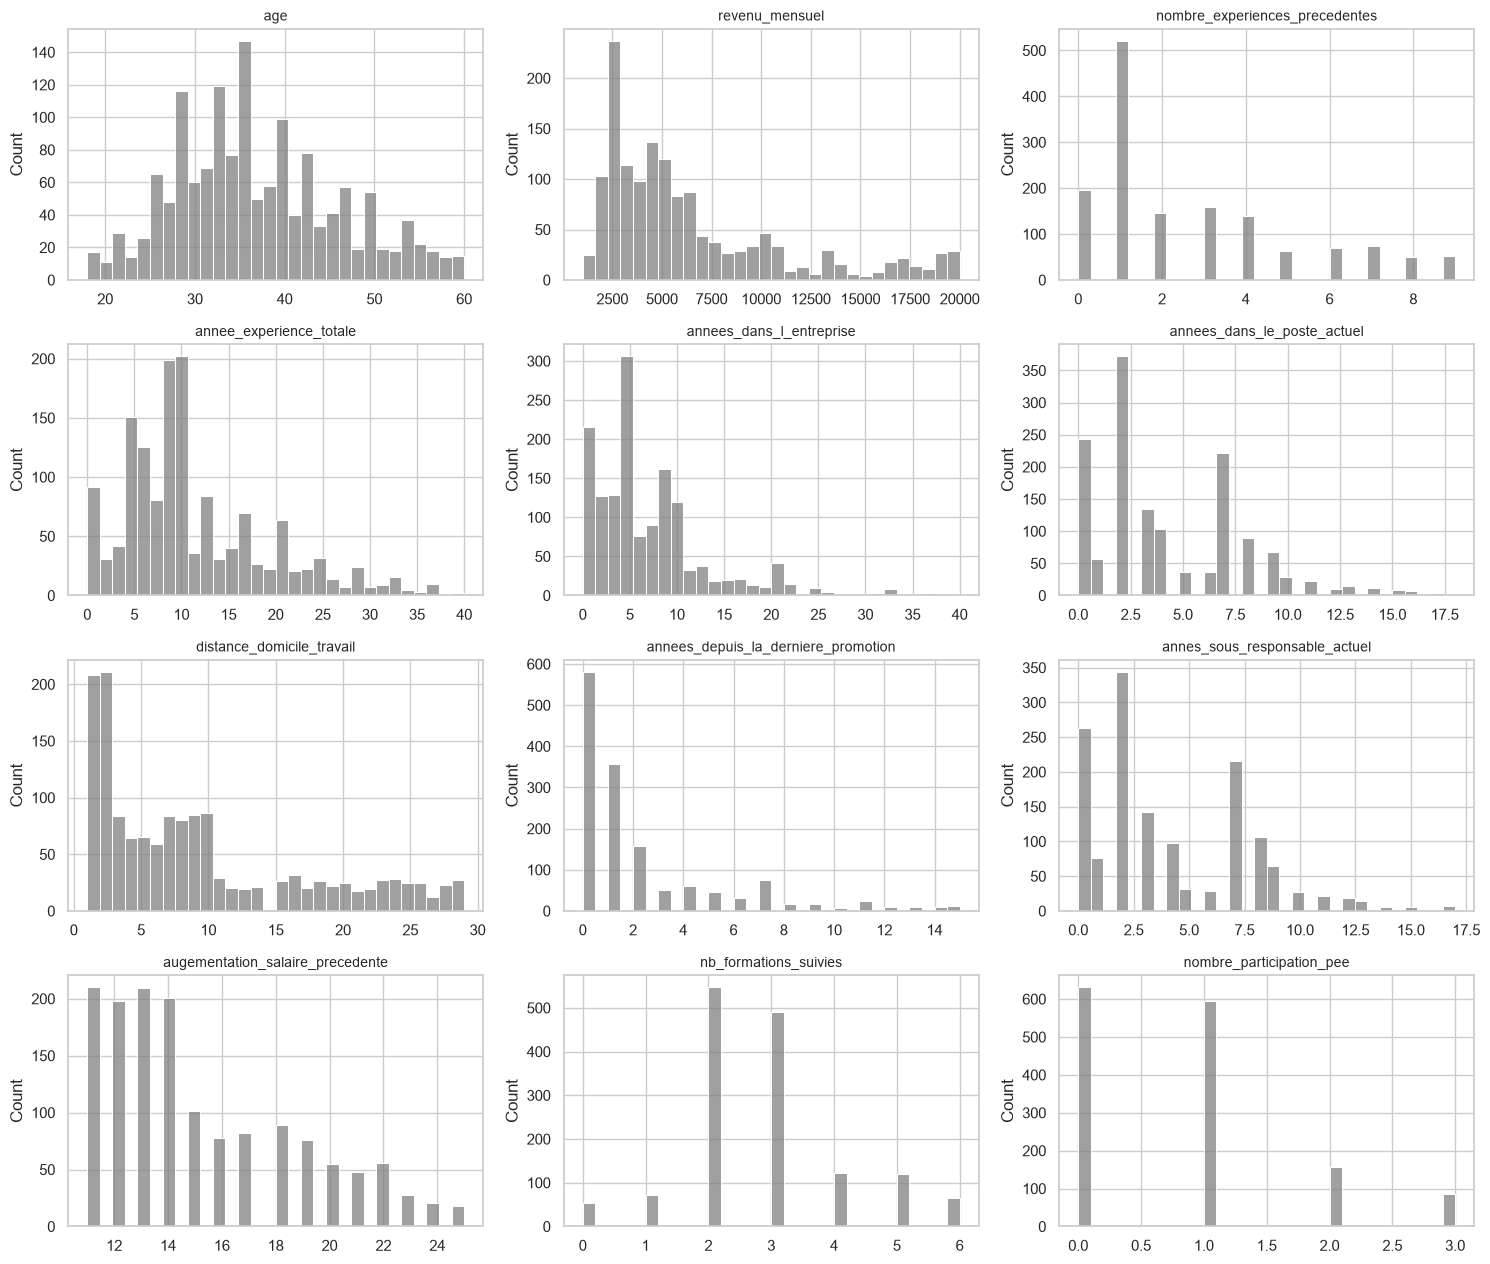

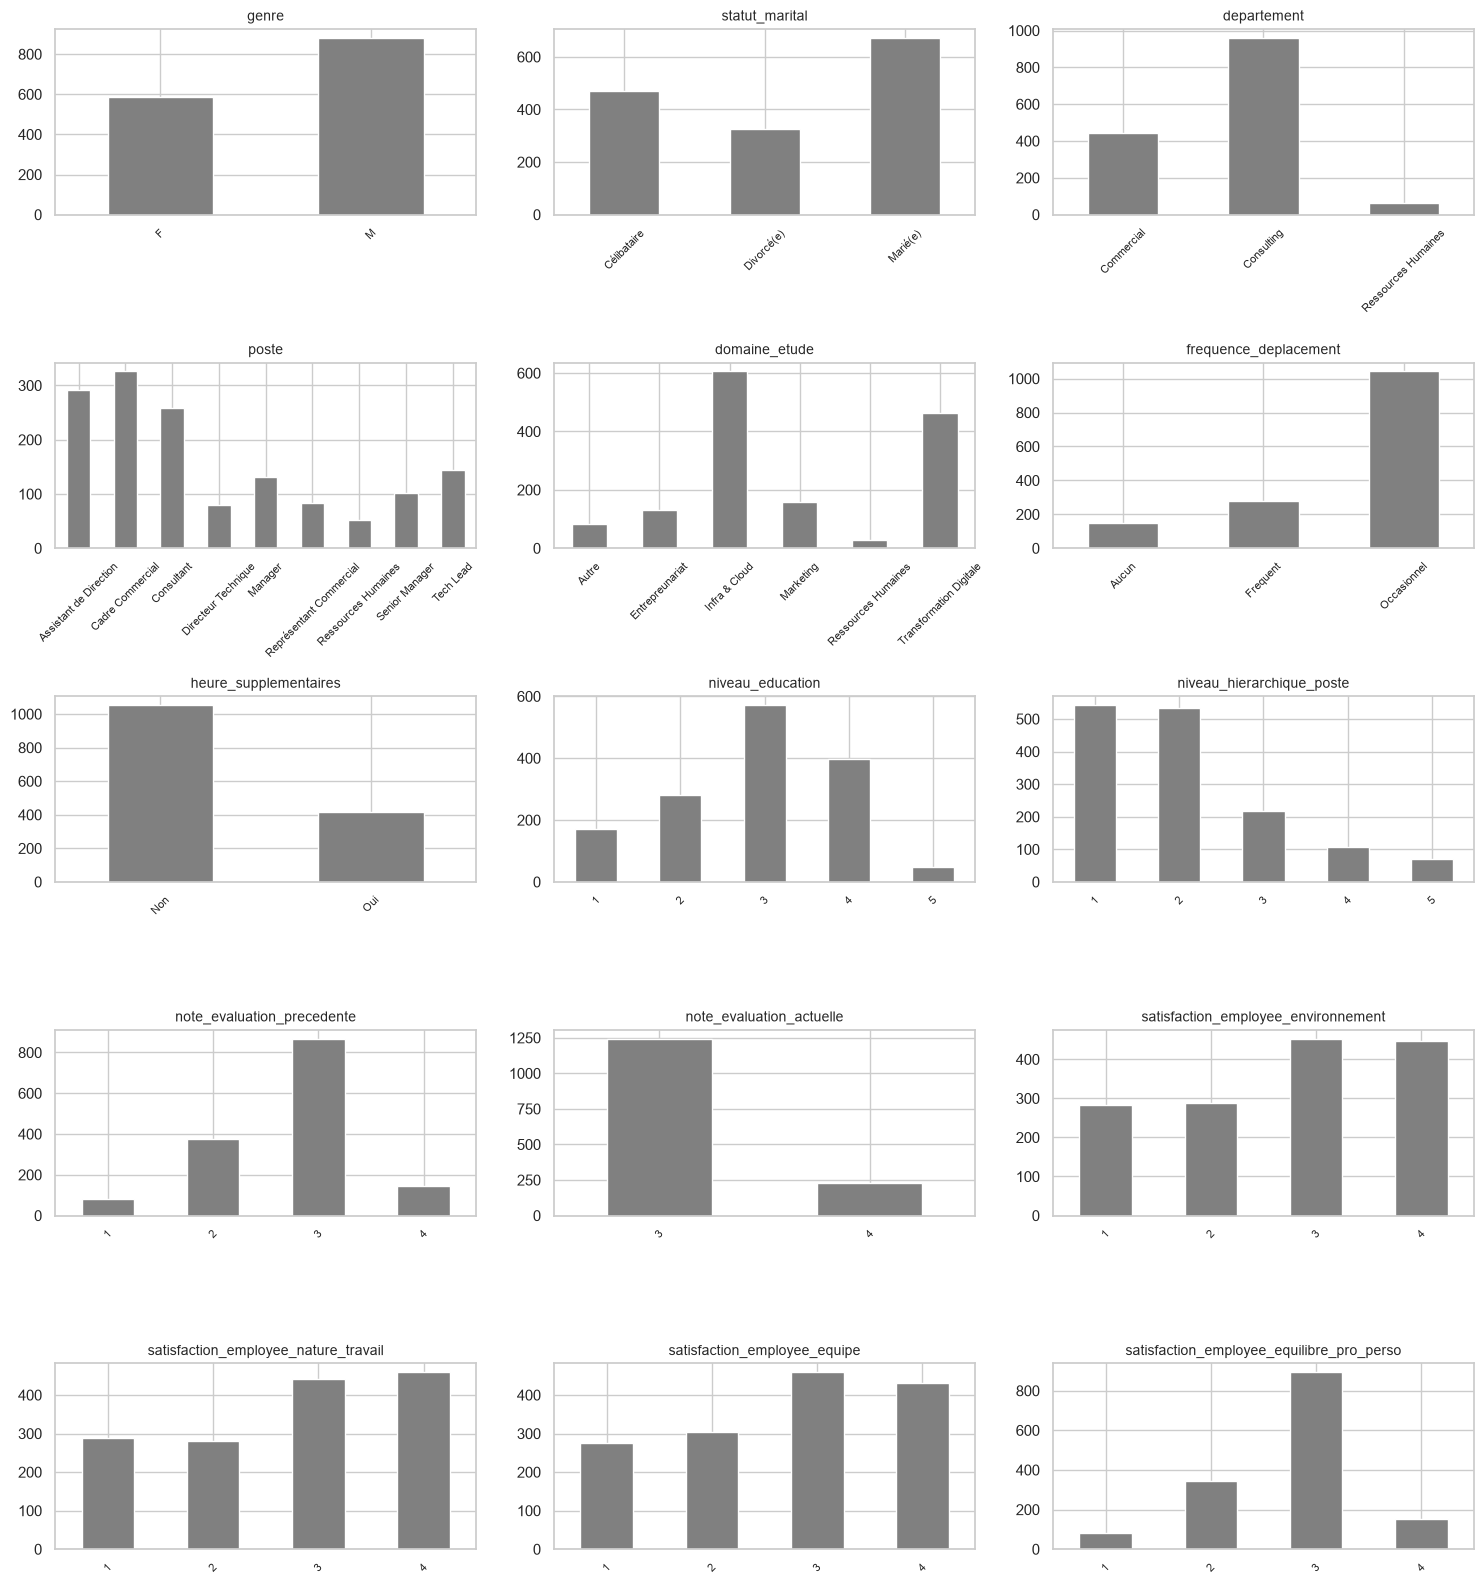

In [17]:
@dataclass(frozen=True)
class VisualiseurExploration:
    """Graphiques de l'exploration, en grilles, avec la palette commune du projet."""

    donnees: pd.DataFrame
    cible: str
    palette: Mapping[str, str]
    nb_colonnes: int = 3

    def _grille(self, nb_graphiques: int, hauteur: float = 3.2):
        """Cree une grille de sous-graphiques et masque les cases inutilisees."""
        nb_lignes = -(-nb_graphiques // self.nb_colonnes)
        fig, axes = plt.subplots(
            nb_lignes,
            self.nb_colonnes,
            figsize=(5 * self.nb_colonnes, hauteur * nb_lignes),
        )
        axes = np.atleast_1d(axes).ravel()
        for ax in axes[nb_graphiques:]:
            ax.set_visible(False)
        return fig, axes

    def histogrammes(self, colonnes: Sequence[str]) -> None:
        """Univarie quantitatif : distribution de chaque variable."""
        fig, axes = self._grille(len(colonnes))
        for ax, colonne in zip(axes, colonnes):
            sns.histplot(self.donnees[colonne], bins=30, color="grey", ax=ax)
            ax.set_title(colonne, fontsize=10)
            ax.set_xlabel("")
        plt.tight_layout()
        plt.show()

    def barres(self, colonnes: Sequence[str]) -> None:
        """Univarie qualitatif : effectif de chaque modalite."""
        fig, axes = self._grille(len(colonnes))
        for ax, colonne in zip(axes, colonnes):
            self.donnees[colonne].value_counts().sort_index().plot.bar(
                color="grey", ax=ax
            )
            ax.set_title(colonne, fontsize=10)
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelrotation=45, labelsize=8)
        plt.tight_layout()
        plt.show()

    def boites_par_cible(self, colonnes: Sequence[str]) -> None:
        """Quantitative contre cible : boites a moustaches par groupe."""
        fig, axes = self._grille(len(colonnes))
        for ax, colonne in zip(axes, colonnes):
            sns.boxplot(
                data=self.donnees,
                x=self.cible,
                y=colonne,
                hue=self.cible,
                order=list(self.palette),
                palette=self.palette,
                legend=False,
                ax=ax,
            )
            ax.set_title(colonne, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("")
        plt.tight_layout()
        plt.show()

    def proportions_par_cible(self, colonnes: Sequence[str]) -> None:
        """Qualitative contre cible : barres empilees en proportion de chaque modalite."""
        fig, axes = self._grille(len(colonnes))
        for ax, colonne in zip(axes, colonnes):
            proportions = pd.crosstab(
                self.donnees[colonne], self.donnees[self.cible], normalize="index"
            )
            proportions[list(self.palette)].plot.bar(
                stacked=True, color=list(self.palette.values()), legend=False, ax=ax
            )
            ax.set_title(colonne, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylim(0, 1)
            ax.tick_params(axis="x", labelrotation=45, labelsize=8)
        # Legende unique, placee au-dessus de la grille pour ne masquer aucune barre
        poignees, libelles = axes[0].get_legend_handles_labels()
        fig.legend(
            poignees,
            libelles,
            title=self.cible,
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(0.5, 1.03),
        )
        plt.tight_layout()
        plt.show()


visualiseur = VisualiseurExploration(
    donnees=df, cible=config.CIBLE, palette=PALETTE_CIBLE
)
visualiseur.histogrammes(VARS_QUANTITATIVES)
visualiseur.barres(VARS_QUALITATIVES)

**Point clé de l'étape.** `revenu_mensuel` est nettement asymétrique à droite (quelques hauts revenus), tout comme `annee_experience_totale` et les colonnes d'ancienneté : ce sont des distributions typiques de durée ou de salaire, pas de forme gaussienne. Les variables de satisfaction et les notes concentrent la majorité des réponses sur 2 à 3 modalités, sans modalité quasi vide. Cette asymétrie justifie de compléter la matrice de Pearson par une matrice de Spearman à l'étape 2.

---
## 11. Analyse bivariée : un graphique adapté à chaque croisement

**Question.** Les écarts mesurés au point 9 se voient-ils sur les distributions complètes, et pas seulement sur les médianes et les taux ?

**Méthode.** Le type de graphique dépend du type des deux variables croisées :

| Croisement | Graphique | Ce qu'il montre |
|---|---|---|
| Quantitative contre cible (qualitative) | Boîtes à moustaches | Décalage de la médiane et de la dispersion entre les deux groupes |
| Qualitative contre cible (qualitative) | Barres empilées en proportion | Part de départs dans chaque modalité |
| Quantitative contre quantitative | Nuage de points coloré par la cible | Relation entre deux variables et position des partants |
| Qualitative contre qualitative | Carte de chaleur | Taux de départ au croisement de deux variables |

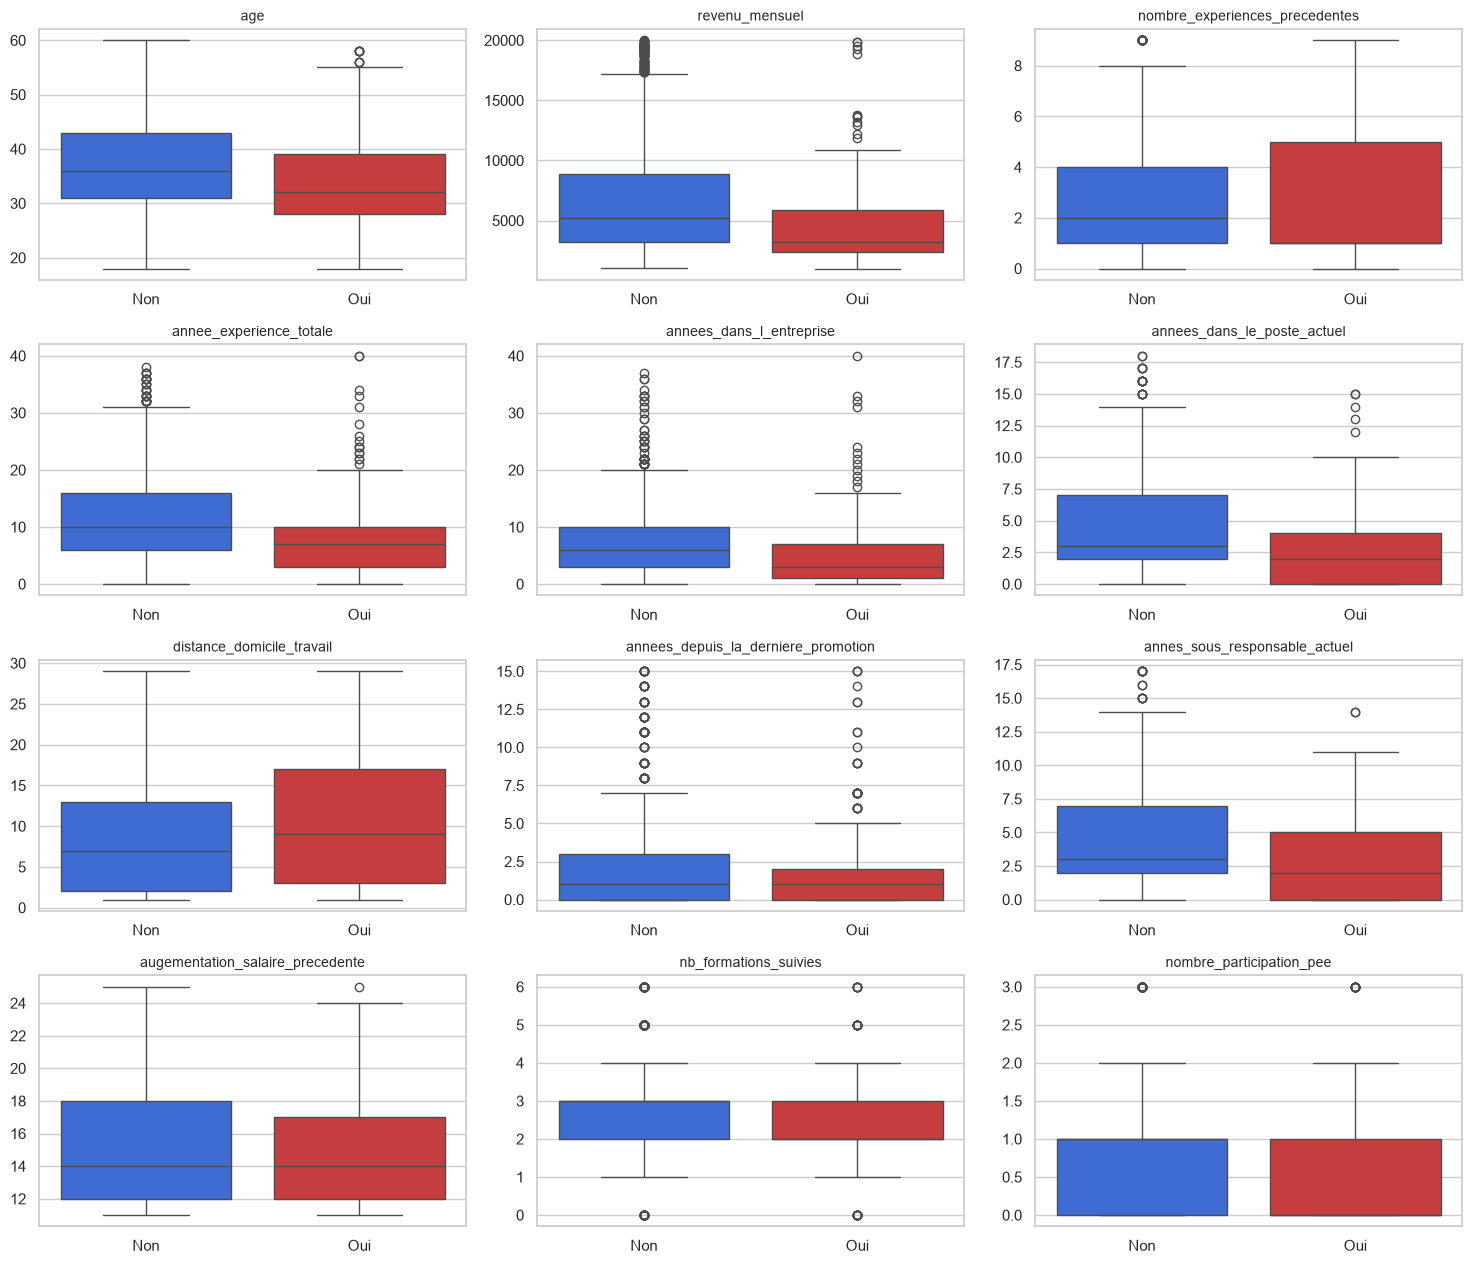

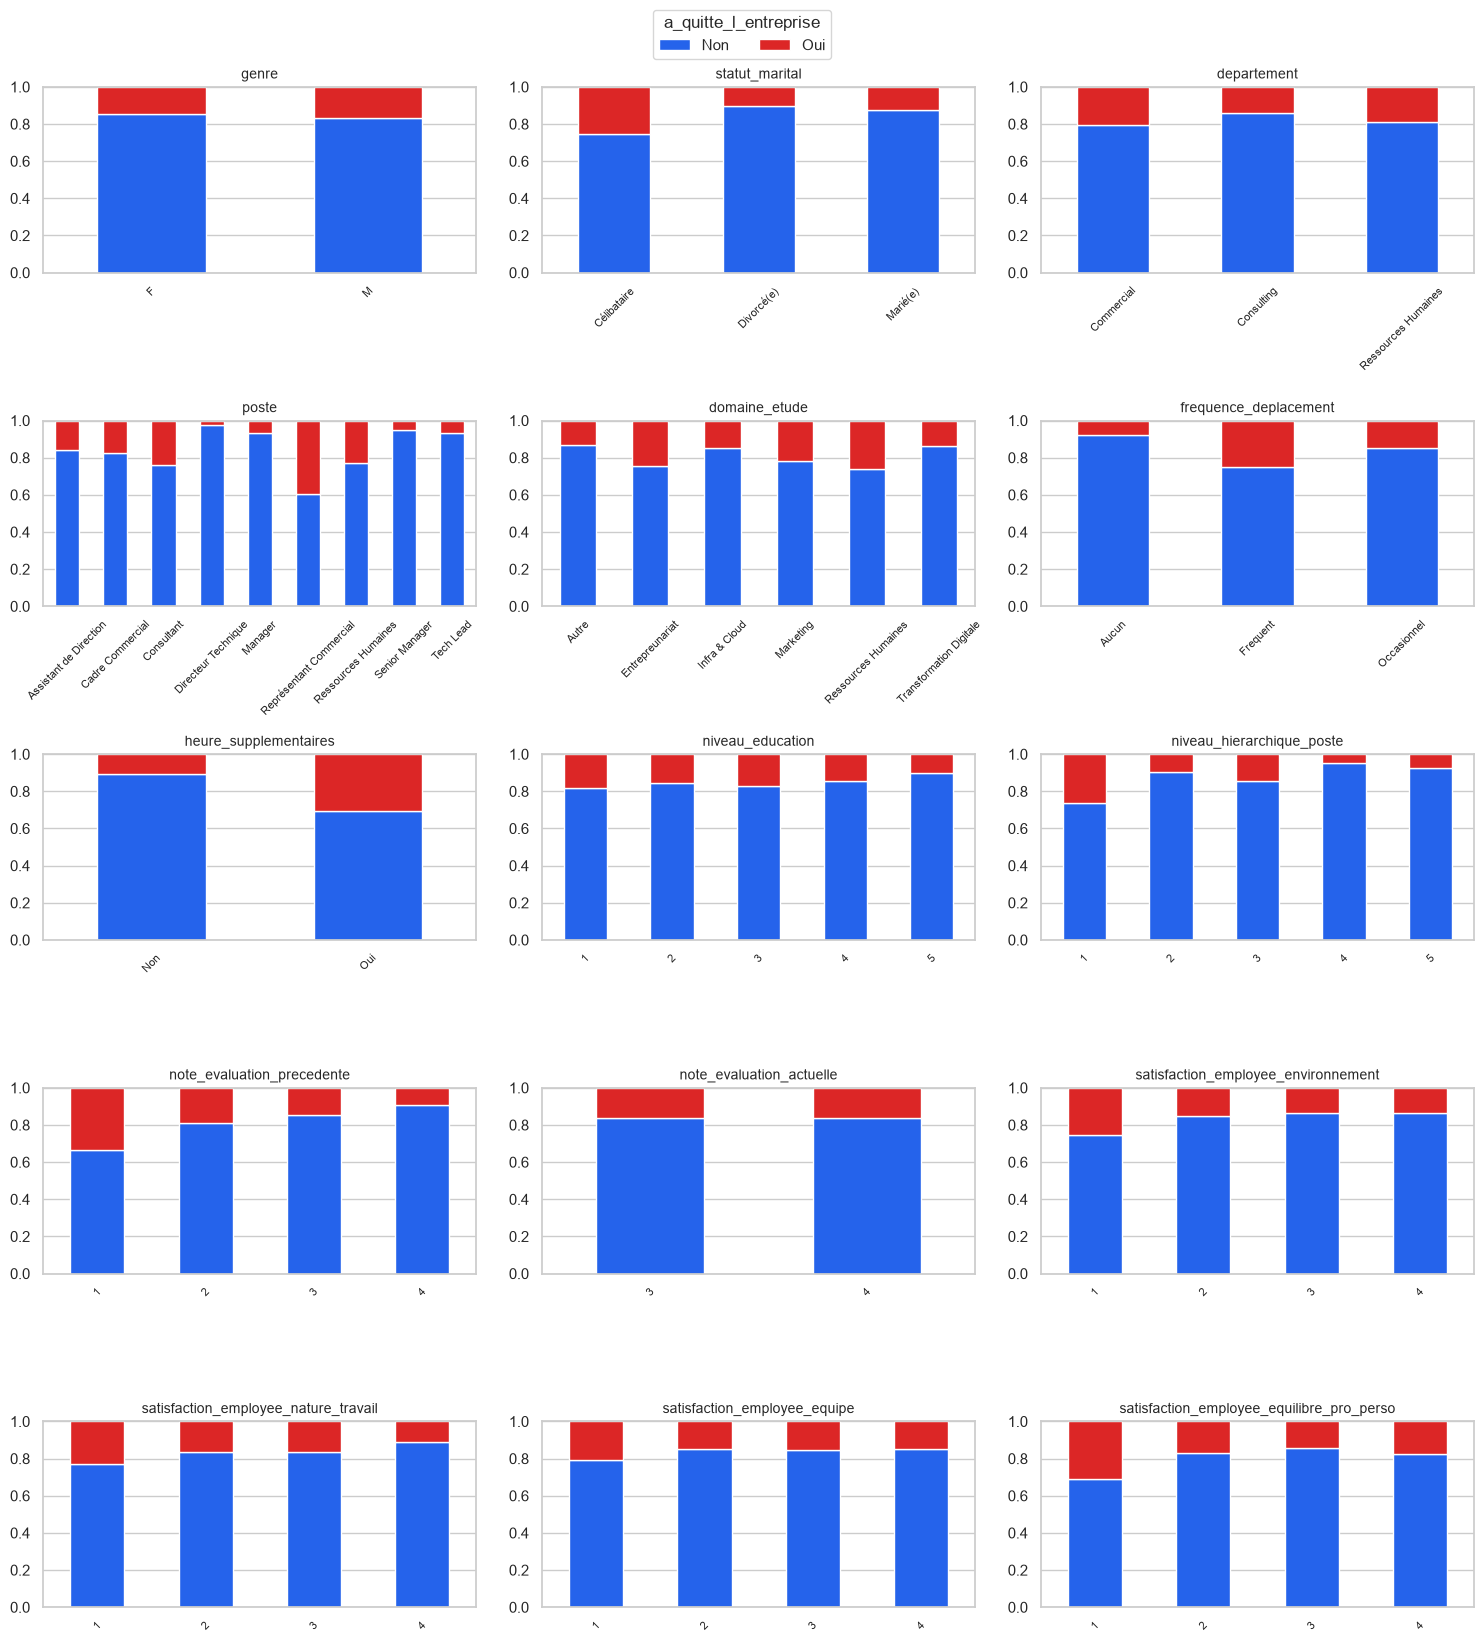

In [18]:
# Quantitatives contre cible, puis qualitatives contre cible
visualiseur.boites_par_cible(VARS_QUANTITATIVES)
visualiseur.proportions_par_cible(VARS_QUALITATIVES)

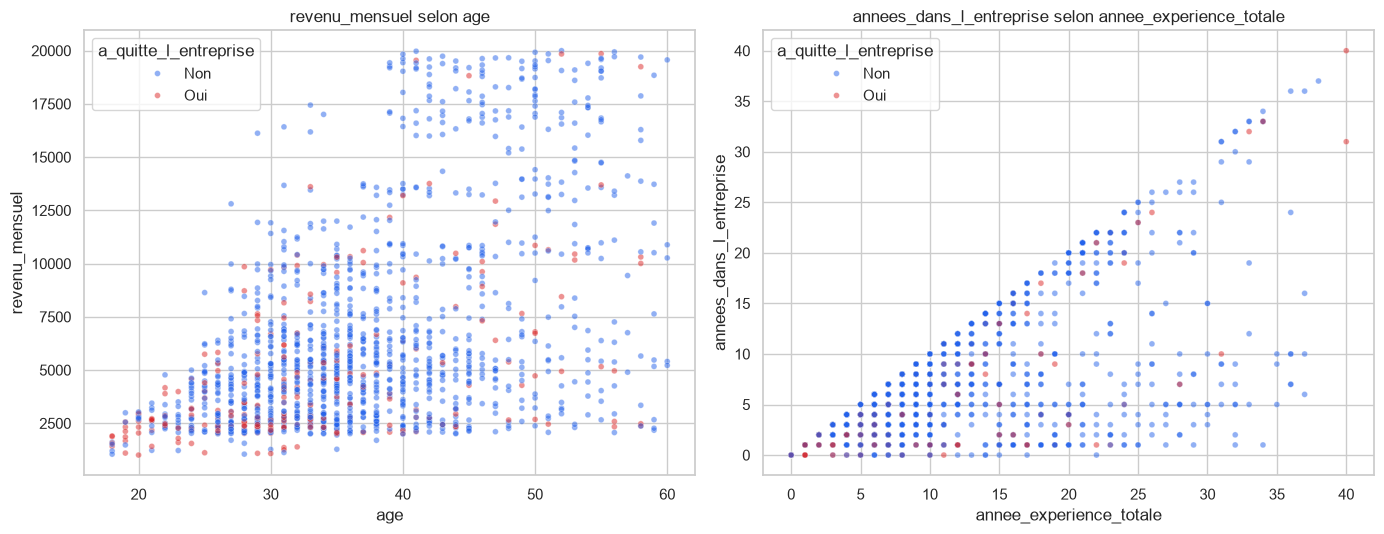

In [19]:
# Quantitative contre quantitative : deux couples issus du bloc age / anciennete / revenu
COUPLES_QUANTITATIFS = [
    ("age", "revenu_mensuel"),
    ("annee_experience_totale", "annees_dans_l_entreprise"),
]

fig, axes = plt.subplots(1, len(COUPLES_QUANTITATIFS), figsize=(14, 5.5))
for ax, (abscisse, ordonnee) in zip(axes, COUPLES_QUANTITATIFS):
    sns.scatterplot(
        data=df,
        x=abscisse,
        y=ordonnee,
        hue=config.CIBLE,
        hue_order=list(PALETTE_CIBLE),
        palette=PALETTE_CIBLE,
        alpha=0.5,
        s=18,
        ax=ax,
    )
    ax.set_title(f"{ordonnee} selon {abscisse}")
plt.tight_layout()
plt.show()

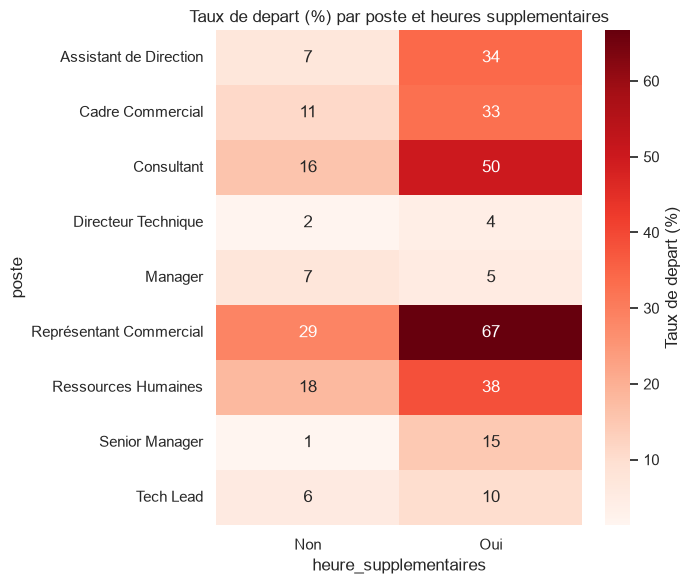

In [20]:
# Qualitative contre qualitative : taux de depart au croisement du poste et des heures supplementaires
taux_croise = (
    df.assign(depart=df[config.CIBLE].eq(config.MODALITE_DEPART))
    .pivot_table(
        index="poste",
        columns="heure_supplementaires",
        values="depart",
        aggfunc="mean",
    )
    .mul(100)
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    taux_croise,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    cbar_kws={"label": "Taux de depart (%)"},
    ax=ax,
)
ax.set_title("Taux de depart (%) par poste et heures supplementaires")
plt.tight_layout()
plt.show()

**Point clé de l'étape.** Les boîtes à moustaches confirment le décalage mesuré au point 9 : les médianes d'âge, de revenu et d'ancienneté des partants (rouge) sont sous celles des restés (bleu), mais les deux distributions se chevauchent largement. Aucune de ces variables ne suffit donc seule à identifier un partant. Les nuages de points montrent que les départs se concentrent dans la zone des profils jeunes, à faible revenu et à faible ancienneté. La carte de chaleur montre que les heures supplémentaires augmentent le taux de départ dans presque tous les postes : c'est un facteur transversal, et non l'effet d'un seul métier. C'est aussi un levier sur lequel les RH peuvent agir directement.

**Synthèse de l'étape 1.** Le DataFrame central compte 1 470 collaborateurs et 27 variables explicatives, sans valeur manquante ni doublon, issu d'une jointure interne un-à-un sur `id_employee`. Deux familles de facteurs distinguent les partants :
- un **profil** (jeunesse, faible ancienneté, faible revenu) que les RH ne pilotent pas directement mais qui délimite la population à risque ;
- des **conditions de travail** sur lesquelles les RH peuvent agir : heures supplémentaires, déplacements fréquents, satisfaction vis-à-vis de l'environnement et de l'équilibre vie professionnelle / vie personnelle.

Ces constats restent descriptifs : ils ne tiennent pas compte des liens entre variables. C'est le modèle (étape 3) puis son interprétation (SHAP) qui mesureront le poids propre de chaque facteur.

---
# Étape 2 - Préparation des features

---
## 12. Création de features métier à partir des données existantes

**Objectif.** Construire, à partir des colonnes existantes, des variables qui parlent directement au SIRH surtout celle dont les variables brutes expriment mal ?

**Mes trois features, chacune formulable en une phrase pour un RH et associée à une action :**

| Feature | Calcul | Ce qu'elle mesure | Action possible pour le SIRH |
|---|---|---|---|
| `satisfaction_minimale` | Minimum des 4 notes de satisfaction | Un seul point de rupture peut suffire à faire partir quelqu'un, même si les autres dimensions vont bien. La moyenne le masquerait | Déclencher un échange dès qu'une dimension est notée 1 |
| `nouveau_responsable` | 1 si le temps passé sous le responsable actuel vaut 0, sinon 0 | Un changement récent de responsable : nouveau management, nouveaux objectifs, relation de confiance à reconstruire | Prévoir un point de suivi après chaque changement de responsable |
| `debut_de_carriere` | 1 si l'expérience professionnelle totale est de 2 ans au plus, sinon 0 | Les premières années de vie professionnelle, où l'on compare encore les employeurs | Parcours d'intégration et de fidélisation des débutants |

**Pourquoi des indicateurs binaires pour le responsable et l'expérience.** Les données contiennent déjà le temps passé sous le responsable actuel et l'expérience totale, en années. Si le risque se concentre sur les toutes premières années, ces variables le diluent : un modèle linéaire donne le même poids à chaque année supplémentaire et ne peut pas isoler ce cap. Je le vérifie ci-dessous, année par année. Ce sont aussi deux événements que le SIRH connaît sans attendre la campagne de sondage annuelle : le changement de responsable par l'organigramme, l'expérience dès l'embauche.

**Un critère professionnel, pas l'âge.** `debut_de_carriere` repose sur l'expérience, et non sur l'âge, qui est une variable sensible (`config.COLONNES_SENSIBLES`). Son seuil de 2 ans (`config.SEUIL_DEBUT_DE_CARRIERE`) est fixé par convention métier, celle du « début de carrière » ou du « jeune diplômé », et non choisi parce qu'il séparerait le mieux les partants dans ces données 

**Sans fuite d'information.** Chaque feature se calcule ligne par ligne, à partir des seules valeurs du collaborateur : aucune statistique n'est apprise sur l'ensemble des données et la cible n'intervient pas. Je peux donc les créer avant le découpage entraînement / validation / test.

**Méthode.** Le DataFrame central n'est pas modifié : les features sont ajoutées à une copie, `df_features`, dont partent l'encodage et `X`. Je mesure le taux de départ selon la valeur de chaque feature, puis elles passent par les mêmes contrôles de redondance que les variables d'origine (points 14 et 15). J'avais aussi envisagé deux indicateurs de mobilité, la part de la carrière passée chez TechNova et la durée moyenne chez les employeurs précédents : mesurés en validation croisée, ils n'apportaient rien au modèle, et je les ai écartés. L'apport des trois features retenues est mesuré au notebook 02.

In [21]:
COLONNES_SATISFACTION = [
    colonne for colonne in df.columns if colonne.startswith("satisfaction_employee")
]


def ajouter_features_metier(donnees: pd.DataFrame) -> pd.DataFrame:
    """Ajoute les trois features metier, calculees ligne par ligne, sans apprentissage."""
    return donnees.assign(
        **{
            config.COL_SATISFACTION_MINIMALE: donnees[COLONNES_SATISFACTION].min(
                axis=1
            ),
            config.COL_NOUVEAU_RESPONSABLE: donnees[config.COL_SOUS_RESPONSABLE_ACTUEL]
            .eq(0)
            .astype(int),
            config.COL_DEBUT_DE_CARRIERE: donnees[config.COL_EXPERIENCE_TOTALE]
            .le(config.SEUIL_DEBUT_DE_CARRIERE)
            .astype(int),
        }
    )


df_features = ajouter_features_metier(df)
assert df_features.index.equals(df.index), "La copie garde les memes collaborateurs"
assert not df_features[list(config.FEATURES_CREEES)].isna().any().any(), (
    "Valeurs manquantes creees"
)
display(df_features[list(config.FEATURES_CREEES)].describe().round(2))

# Taux de depart selon la valeur de chaque feature
depart = df_features[config.CIBLE].eq(config.MODALITE_DEPART)
signal_features = pd.concat(
    [
        depart.groupby(df_features[feature])
        .agg(collaborateurs="size", taux_depart="mean")
        .assign(feature=feature)
        for feature in config.FEATURES_CREEES
    ]
)
display(signal_features.set_index("feature", append=True).swaplevel().round(3))

,satisfaction_minimale,nouveau_responsable,debut_de_carriere
count,1470.00,1470.00,1470.00
mean,1.66,0.18,0.08
std,0.75,0.38,0.28
min,1.00,0.00,0.00
25%,1.00,0.00,0.00
50%,1.00,0.00,0.00
75%,2.00,0.00,0.00
max,4.00,1.00,1.00


collaborateurs  taux_depart
feature                                             
satisfaction_minimale 1             737        0.212
                      2             500        0.122
                      3             227        0.088
                      4               6        0.000
nouveau_responsable   0            1207        0.126
                      1             263        0.323
debut_de_carriere     0            1347        0.136
                      1             123        0.439

collaborateurs  taux_depart
feature               modalite                             
satisfaction_minimale Faible               737         21.2
                      Moyenne              500         12.2
                      Élevée               233          8.6
nouveau_responsable   Non                 1207         12.6
                      Oui                  263         32.3
debut_de_carriere     Non                 1347         13.6
                      Oui                  123         43.9

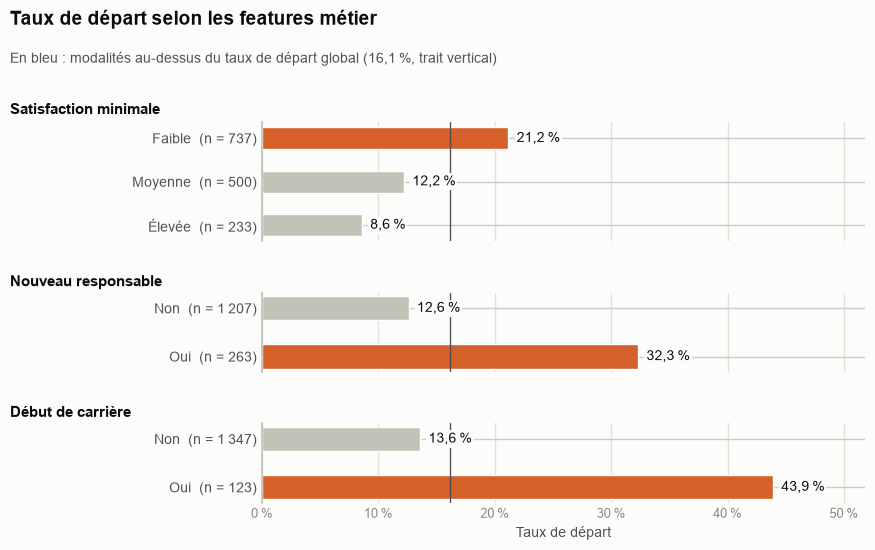

In [33]:
# =============================================================================
# Visualisation des features métier : taux de départ par modalité
# -----------------------------------------------------------------------------
# À exécuter dans le notebook APRÈS la cellule qui crée `df_features`
# (fonction `ajouter_features_metier`). Réutilise `config`, `df_features`.
# =============================================================================
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter
from matplotlib.transforms import blended_transform_factory

# -----------------------------------------------------------------------------
# 1. Paramètres d'affichage (seul bloc à adapter si besoin)
# -----------------------------------------------------------------------------
# Titre lisible de chaque panneau, dans l'ordre d'affichage
LIBELLES_FEATURES = {
    config.COL_SATISFACTION_MINIMALE: "Satisfaction minimale",
    config.COL_NOUVEAU_RESPONSABLE: "Nouveau responsable",
    config.COL_DEBUT_DE_CARRIERE: "Début de carrière",
}

# La satisfaction minimale est un score 1 à 4 (minimum des notes de satisfaction).
# On le regroupe en 3 niveaux lisibles : 1 -> Faible, 2 -> Moyenne, 3-4 -> Élevée.
# Les intervalles sont fermés à droite : (0, 1], (1, 2], (2, 4].
BORNES_SATISFACTION = [0, 1, 2, 4]
NIVEAUX_SATISFACTION = ["Faible", "Moyenne", "Élevée"]

# Les deux autres features sont des indicateurs 0/1
LIBELLES_BINAIRES = {0: "Non", 1: "Oui"}
NIVEAUX_BINAIRES = ["Non", "Oui"]

# Palette sobre : une seule couleur porte le message (au-dessus du taux global),
# le reste reste en gris pour ne pas concurrencer l'information principale.
COULEUR_AU_DESSUS = "#d6602a"  # rouge : modalité plus à risque que la moyenne
COULEUR_EN_DESSOUS = "#c3c2b7"  # gris : modalité sous la moyenne
ENCRE_PRINCIPALE = "#0b0b0b"  # titres et valeurs
ENCRE_SECONDAIRE = "#52514e"  # sous-titre, libellés de modalités, trait global
ENCRE_DISCRETE = "#898781"  # graduations de l'axe
COULEUR_GRILLE = "#e1e0d9"  # quadrillage très léger
COULEUR_FOND = "#fcfcfb"


def formater_pourcentage(valeur: float, decimales: int = 1) -> str:
    """Formate une valeur en pourcentage à la française : 16.08 -> '16,1 %'."""
    return f"{valeur:.{decimales}f}".replace(".", ",") + " %"


# -----------------------------------------------------------------------------
# 2. Passage des valeurs brutes aux modalités lisibles
# -----------------------------------------------------------------------------
def libeller_modalites(donnees: pd.DataFrame) -> pd.DataFrame:
    """Traduit chaque feature créée en modalités ordonnées (catégories pandas).

    L'ordre des catégories fixe l'ordre des barres dans le graphique.
    """

    def binaire(colonne: str) -> pd.Categorical:
        return pd.Categorical(
            donnees[colonne].map(LIBELLES_BINAIRES),
            categories=NIVEAUX_BINAIRES,
            ordered=True,
        )

    return pd.DataFrame(
        {
            config.COL_SATISFACTION_MINIMALE: pd.cut(
                donnees[config.COL_SATISFACTION_MINIMALE],
                bins=BORNES_SATISFACTION,
                labels=NIVEAUX_SATISFACTION,
            ),
            config.COL_NOUVEAU_RESPONSABLE: binaire(config.COL_NOUVEAU_RESPONSABLE),
            config.COL_DEBUT_DE_CARRIERE: binaire(config.COL_DEBUT_DE_CARRIERE),
        },
        index=donnees.index,
    )


modalites = libeller_modalites(df_features)
# Garde-fou : une valeur hors bornes (ex. satisfaction sur une autre échelle)
# deviendrait NaN et disparaîtrait silencieusement du graphique.
assert not modalites.isna().any().any(), (
    "Valeur hors bornes : ajuster BORNES_SATISFACTION"
)

# -----------------------------------------------------------------------------
# 3. Taux de départ par modalité (même logique que `signal_features`)
# -----------------------------------------------------------------------------
depart = df_features[config.CIBLE].eq(config.MODALITE_DEPART)
taux_global = depart.mean() * 100  # référence : taux de départ de toute la population

taux_par_modalite = pd.concat(
    [
        depart.groupby(modalites[feature], observed=False)
        .agg(collaborateurs="size", taux_depart="mean")
        .rename_axis("modalite")
        .reset_index()
        .assign(feature=feature, taux_depart=lambda t: t["taux_depart"] * 100)
        for feature in LIBELLES_FEATURES
    ],
    ignore_index=True,
)
# Vue tableau du graphique (utile pour vérifier les chiffres ou les citer)
display(taux_par_modalite.set_index(["feature", "modalite"]).round(1))


# -----------------------------------------------------------------------------
# 4. Graphique : un panneau de barres horizontales par feature
# -----------------------------------------------------------------------------
def tracer_taux_depart(taux: pd.DataFrame, taux_reference: float) -> plt.Figure:
    """Trace un panneau par feature, barres = taux de départ de chaque modalité.

    - Bleu si la modalité dépasse le taux global, gris sinon.
    - Trait vertical = taux global, pour juger chaque barre d'un coup d'œil.
    - Effectif de chaque modalité rappelé à gauche (un taux sur 20 personnes
      ne pèse pas comme un taux sur 800).
    """
    features = list(LIBELLES_FEATURES)
    nb_barres = [int((taux["feature"] == f).sum()) for f in features]

    # Hauteur de chaque panneau proportionnelle à son nombre de barres,
    # pour que toutes les barres aient la même épaisseur.
    fig, axes = plt.subplots(
        nrows=len(features),
        ncols=1,
        sharex=True,
        figsize=(9, 1.6 + 0.55 * sum(nb_barres)),
        gridspec_kw={"height_ratios": nb_barres, "hspace": 0.55},
        facecolor=COULEUR_FOND,
    )

    # Échelle commune à tous les panneaux, avec de la place pour les étiquettes
    x_max = max(taux["taux_depart"].max(), taux_reference) * 1.18

    for ax, feature in zip(axes, features):
        bloc = taux[taux["feature"] == feature].reset_index(drop=True)
        positions = range(len(bloc))
        couleurs = [
            COULEUR_AU_DESSUS if valeur > taux_reference else COULEUR_EN_DESSOUS
            for valeur in bloc["taux_depart"]
        ]

        # Barres (épaisseur 0,5 de la bande : le reste sert de respiration)
        ax.barh(positions, bloc["taux_depart"], height=0.5, color=couleurs, zorder=2)

        # Valeur en bout de barre, en encre (jamais dans la couleur de la barre)
        for position, valeur in zip(positions, bloc["taux_depart"]):
            ax.annotate(
                formater_pourcentage(valeur),
                xy=(valeur, position),
                xytext=(6, 0),
                textcoords="offset points",
                va="center",
                fontsize=10,
                color=ENCRE_PRINCIPALE,
                # fond couleur page : masque le trait global si l'étiquette le croise
                bbox={
                    "boxstyle": "square,pad=0.15",
                    "facecolor": COULEUR_FOND,
                    "edgecolor": "none",
                },
                zorder=4,
            )

        # Libellé de modalité + effectif sur l'axe vertical
        ax.set_yticks(list(positions))
        ax.set_yticklabels(
            [
                f"{modalite}  (n = {effectif:,})".replace(",", " ")
                for modalite, effectif in zip(bloc["modalite"], bloc["collaborateurs"])
            ],
            fontsize=10,
            color=ENCRE_SECONDAIRE,
        )
        ax.invert_yaxis()  # première modalité en haut

        # Trait de référence : taux de départ global
        ax.axvline(taux_reference, color=ENCRE_SECONDAIRE, linewidth=1, zorder=3)

        # Titre de panneau aligné sur la marge gauche de la figure (x en
        # coordonnées figure, y en coordonnées du panneau : juste au-dessus)
        ax.text(
            0.02,
            1.04,
            LIBELLES_FEATURES[feature],
            transform=blended_transform_factory(fig.transFigure, ax.transAxes),
            ha="left",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color=ENCRE_PRINCIPALE,
        )

        # Habillage minimal : quadrillage vertical discret, pas de cadre
        ax.set_facecolor(COULEUR_FOND)
        ax.set_xlim(0, x_max)
        ax.grid(axis="x", color=COULEUR_GRILLE, linewidth=1, zorder=0)
        ax.tick_params(axis="y", length=0)
        ax.tick_params(axis="x", length=0, colors=ENCRE_DISCRETE, labelsize=9)
        for cote in ("top", "right", "bottom"):
            ax.spines[cote].set_visible(False)
        ax.spines["left"].set_color(COULEUR_EN_DESSOUS)  # ligne de base des barres

    # Axe des x en pourcentage, affiché sous le dernier panneau uniquement
    axes[-1].xaxis.set_major_formatter(
        FuncFormatter(lambda valeur, _: formater_pourcentage(valeur, decimales=0))
    )
    axes[-1].set_xlabel("Taux de départ", fontsize=10, color=ENCRE_SECONDAIRE)

    # Titre et sous-titre de la figure (le sous-titre explique la couleur)
    fig.suptitle(
        "Taux de départ selon les features métier",
        x=0.02,
        y=0.995,
        ha="left",
        fontsize=14,
        fontweight="bold",
        color=ENCRE_PRINCIPALE,
    )
    fig.text(
        0.02,
        0.995 - 0.42 / fig.get_figheight(),
        f"En bleu : modalités au-dessus du taux de départ global "
        f"({formater_pourcentage(taux_reference)}, trait vertical)",
        ha="left",
        va="top",
        fontsize=10,
        color=ENCRE_SECONDAIRE,
    )

    fig.subplots_adjust(
        left=0.30, right=0.97, top=1 - 1.15 / fig.get_figheight(), bottom=0.09
    )
    return fig


fig = tracer_taux_depart(taux_par_modalite, taux_global)
plt.show()

# Pour l'exporter (rapport, soutenance) :
# fig.savefig("taux_depart_features_metier.png", dpi=200, bbox_inches="tight")

**Point clé de l'étape.** Les trois features distinguent nettement les partants, et les deux indicateurs binaires captent bien une rupture des premières années :
- **`debut_de_carriere`** : 43,9 % de départs chez les 123 collaborateurs qui ont 2 ans d'expérience ou moins, contre 13,6 % pour les autres, plus de trois fois plus. La rupture est nette : près d'un sur deux part avec 0 ou 1 an d'expérience (45,5 % et 49,4 %), 29,0 % à 2 ans, puis le taux baisse lentement et irrégulièrement, de 21 % à 3 ans à environ 10 % au-delà de 9 ans. Le seuil conventionnel de 2 ans tombe donc juste après la rupture ;
- **`nouveau_responsable`** : les 263 collaborateurs qui viennent de changer de responsable partent à 32,3 % ; dès la deuxième année, le taux tombe à 14,5 %, puis reste entre 6 % et 15 % sans tendance marquée. La feature rend explicite cet effet de seuil, avec un taux de départ deux fois et demie plus élevé que chez les autres collaborateurs (12,6 %) ;
- **`satisfaction_minimale`** : 21,2 % de départs quand au moins une dimension est notée 1, 12,2 % quand le minimum est 2, 8,8 % quand il est 3. Un collaborateur sur deux (737 sur 1 470) a au moins une dimension au plus bas.

Les trois features sont ajoutées à `df_features` et au dictionnaire des variables. Elles passent maintenant par l'encodage et les contrôles de redondance, comme les variables d'origine.

---
## 13. Choix de l'encodage selon le sens métier





**Mes choix d'encodage, variable par variable :**

| Nature | Variables | Encodage | Justification |
|---|---|---|---|
| Binaire | `genre`, `heure_supplementaires` | 0 / 1 | Deux modalités : une seule colonne suffit |
| Ordinale en texte | `frequence_deplacement` | Aucun = 0, Occasionnel = 1, Frequent = 2 | L'ordre a un sens métier : plus on se déplace, plus la contrainte est forte |
| Ordinale déjà numérique | satisfactions, notes d'évaluation, `niveau_education`, `niveau_hierarchique_poste` | Conservées telles quelles | L'échelle 1 à 4 (ou 1 à 5) porte déjà l'ordre |
| Nominale | `departement`, `poste`, `statut_marital`, `domaine_etude` | One-hot (une colonne 0 / 1 par modalité) | Aucun ordre entre les modalités |

**Pourquoi ces encodages ne demandent aucun `fit()`.** Les correspondances sont écrites à la main et les modalités sont connues et fixes : elles ne dépendent pas des données. Je peux donc les appliquer avant le découpage entraînement / validation / test sans fuite d'information. La mise à l'échelle, elle, apprend une moyenne et un écart-type sur les données : elle sera ajustée à l'étape 3, sur l'entraînement seulement.

**Méthode.** Je regroupe ces règles dans une classe, `PreparateurFeatures`, pour pouvoir rejouer exactement les mêmes transformations sur de nouvelles données. Les correspondances passent par `.apply()` : une modalité inconnue lève une erreur au lieu de produire une valeur manquante silencieuse.

In [23]:
# --- Regles d'encodage, definies une seule fois pour tout le notebook ---
CORRESPONDANCES = {
    "genre": {"F": 0, "M": 1},
    "heure_supplementaires": {"Non": 0, "Oui": 1},
    "frequence_deplacement": {"Aucun": 0, "Occasionnel": 1, "Frequent": 2},
}
COLONNES_NOMINALES = ["departement", "poste", "statut_marital", "domaine_etude"]
COLONNES_ORDINALES_NUMERIQUES = [
    "niveau_education",
    "niveau_hierarchique_poste",
    "note_evaluation_precedente",
    "note_evaluation_actuelle",
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
]

# Chaque variable qualitative doit recevoir une et une seule regle d'encodage
regles_declarees = (
    list(CORRESPONDANCES) + COLONNES_NOMINALES + COLONNES_ORDINALES_NUMERIQUES
)
assert sorted(regles_declarees) == sorted(VARS_QUALITATIVES), (
    "Variable qualitative sans regle, ou en double"
)


@dataclass(frozen=True)
class PreparateurFeatures:
    """Transforme le DataFrame central en features numeriques X et en cible binaire y.

    Toutes les transformations sont des correspondances fixes : aucune n'apprend
    des donnees, la classe peut donc etre appliquee avant le decoupage.
    """

    correspondances: Mapping[str, Mapping[str, int]]
    colonnes_nominales: Sequence[str]
    cible: str
    modalite_positive: str
    colonnes_identifiant: Sequence[str] = ("id_employee",)

    def construire_cible(self, donnees: pd.DataFrame) -> pd.Series:
        """Cible binaire : 1 pour un depart, 0 sinon."""
        return (
            donnees[self.cible].eq(self.modalite_positive).astype(int).rename("depart")
        )

    def encoder_par_correspondance(self, donnees: pd.DataFrame) -> pd.DataFrame:
        """Applique les correspondances binaires et ordinales, sans toucher aux nominales."""
        resultat = donnees.drop(columns=[self.cible, *self.colonnes_identifiant])
        for colonne, correspondance in self.correspondances.items():
            # Une modalite absente de la correspondance leve un KeyError explicite
            resultat[colonne] = resultat[colonne].apply(
                lambda valeur: correspondance[valeur]
            )
        return resultat

    def encoder_nominales(self, donnees: pd.DataFrame) -> pd.DataFrame:
        """Encode les variables nominales en one-hot (une colonne 0 / 1 par modalite)."""
        return pd.get_dummies(donnees, columns=list(self.colonnes_nominales), dtype=int)

    def transformer(
        self,
        donnees: pd.DataFrame,
        colonnes_a_retirer: Sequence[str] = (),
    ) -> tuple[pd.DataFrame, pd.Series]:
        """Enchaine toutes les transformations et renvoie le couple (X, y)."""
        features = self.encoder_par_correspondance(donnees).drop(
            columns=list(colonnes_a_retirer)
        )
        return self.encoder_nominales(features), self.construire_cible(donnees)


preparateur = PreparateurFeatures(
    correspondances=CORRESPONDANCES,
    colonnes_nominales=COLONNES_NOMINALES,
    cible=config.CIBLE,
    modalite_positive=config.MODALITE_DEPART,
)

# Controle sur de vraies lignes : les colonnes encodees doivent etre numeriques
features_numeriques = preparateur.encoder_par_correspondance(df_features).drop(
    columns=COLONNES_NOMINALES
)
display(features_numeriques[list(CORRESPONDANCES)].head())
print(
    f"{features_numeriques.shape[1]} variables numeriques disponibles pour les correlations"
)

,genre,heure_supplementaires,frequence_deplacement
0,0,1,1
1,1,0,2
2,1,1,1
3,0,1,2
4,1,0,1


26 variables numeriques disponibles pour les correlations


**Point clé de l'étape.** Les trois correspondances s'appliquent sans erreur : toutes les modalités observées sont couvertes. J'obtiens 26 variables numériques (12 quantitatives, les 3 features créées au point 12, 8 ordinales déjà numériques, 3 encodées par correspondance). Les 4 nominales seront encodées en one-hot à la toute fin, une fois les redondances traitées.

---
## 14. Corrélations linéaires : matrice de Pearson

**Question.** Deux variables portent-elles la même information de manière quasi linéaire ?

Deux variables presque parfaitement corrélées n'apportent qu'une seule information au modèle. Pour une régression logistique, elles rendent les coefficients instables : le poids se répartit arbitrairement entre les deux, ce qui fausse aussi l'interprétation.

**Quelles variables entrent dans le calcul.** Le coefficient de Pearson mesure une relation linéaire entre deux grandeurs numériques. J'y inclus les quantitatives, les ordinales (leur codage respecte un ordre) et les binaires codées 0 / 1. **J'en exclus les nominales** : un numéro de poste ou de département n'a pas de valeur numérique, et une corrélation calculée dessus ne voudrait rien dire.

**Règle de décision.** Au-delà de 0,8 en valeur absolue, je retire l'une des deux variables, en gardant celle qui a le plus de sens pour le métier.

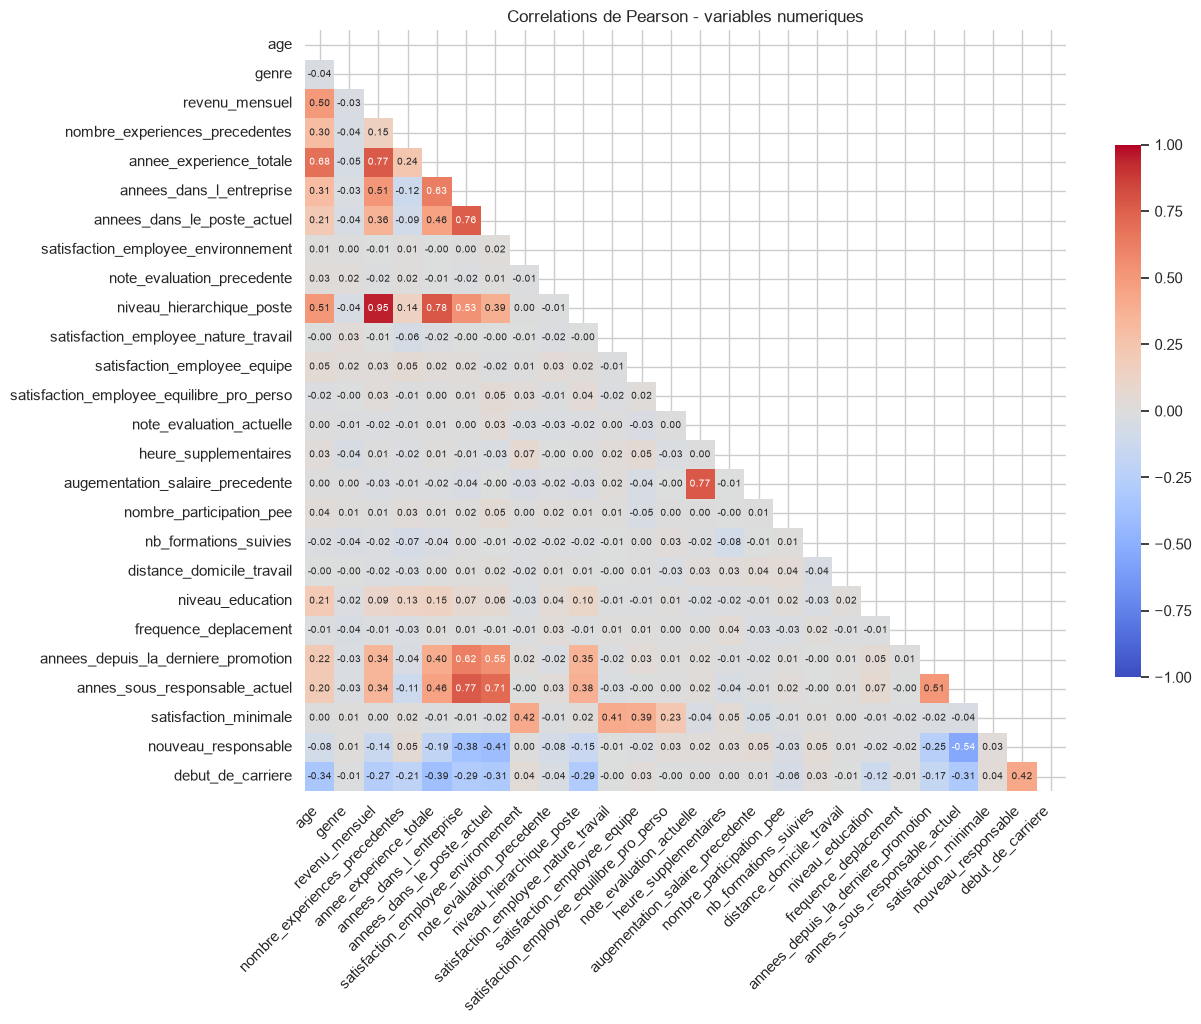

,variable_1,variable_2,correlation
0,niveau_hierarchique_poste,revenu_mensuel,0.95


In [24]:
SEUIL_CORRELATION_FORTE = 0.8


def afficher_matrice_correlation(matrice: pd.DataFrame, titre: str) -> None:
    """Affiche le triangle inferieur d'une matrice de correlation."""
    masque = np.triu(np.ones_like(matrice, dtype=bool))
    taille = max(8, 0.5 * len(matrice))
    fig, ax = plt.subplots(figsize=(taille, taille * 0.8))
    sns.heatmap(
        matrice,
        mask=masque,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        cbar_kws={"shrink": 0.7},
        ax=ax,
    )
    ax.set_title(titre)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def lister_paires_correlees(matrice: pd.DataFrame, seuil: float) -> pd.DataFrame:
    """Liste les paires de variables dont la correlation depasse le seuil en valeur absolue."""
    triangle = matrice.where(np.tril(np.ones_like(matrice, dtype=bool), k=-1))
    paires = triangle.stack().rename("correlation").reset_index()
    paires.columns = ["variable_1", "variable_2", "correlation"]
    return (
        paires[paires["correlation"].abs() > seuil]
        .sort_values("correlation", key=np.abs, ascending=False, ignore_index=True)
        .round(3)
    )


matrice_pearson = features_numeriques.corr(method="pearson")
afficher_matrice_correlation(
    matrice_pearson, "Correlations de Pearson - variables numeriques"
)

paires_pearson = lister_paires_correlees(matrice_pearson, SEUIL_CORRELATION_FORTE)
display(paires_pearson)

In [25]:
# Decision : pour chaque paire au-dessus du seuil, la variable retiree et la raison
VARIABLES_REDONDANTES = {
    "niveau_hierarchique_poste": (
        "Redondant avec revenu_mensuel, que je conserve : plus fin (montant continu "
        "contre 5 niveaux) et directement actionnable par les RH."
    ),
}

# Chaque paire au-dessus du seuil doit etre traitee par au moins un retrait
paires_non_traitees = paires_pearson[
    ~paires_pearson["variable_1"].isin(VARIABLES_REDONDANTES)
    & ~paires_pearson["variable_2"].isin(VARIABLES_REDONDANTES)
]
assert paires_non_traitees.empty, (
    f"Paires fortement correlees sans decision : {paires_non_traitees}"
)

for variable, raison in VARIABLES_REDONDANTES.items():
    print(f"Retiree : {variable} -> {raison}")

Retiree : niveau_hierarchique_poste -> Redondant avec revenu_mensuel, que je conserve : plus fin (montant continu contre 5 niveaux) et directement actionnable par les RH.


**Ma décision.** Une seule paire dépasse le seuil de 0,8 : `revenu_mensuel` et `niveau_hierarchique_poste` (environ 0,95). Le salaire suit presque mécaniquement le niveau hiérarchique : les deux variables disent la même chose. Je retire `niveau_hierarchique_poste` et je garde `revenu_mensuel`, plus précis et directement actionnable. Les autres corrélations restent sous 0,8, y compris dans le bloc ancienneté / expérience / âge : ces variables sont liées sans être interchangeables, je les conserve.

Les trois features créées au point 12 restent aussi sous le seuil. `nouveau_responsable` est corrélée à -0,54 avec `annes_sous_responsable_actuel`, dont elle est issue ; `debut_de_carriere` l'est au plus à 0,42, avec `nouveau_responsable` (un débutant a souvent un responsable récent), et seulement à -0,34 avec l'âge : c'est bien un critère professionnel, pas un substitut de l'âge. Aucune n'est redondante.

---
## 15. Relations non linéaires : pairplot et matrice de Spearman

**Question.** Existe-t-il des relations fortes que Pearson ne capte pas parce qu'elles ne sont pas linéaires ?

Pearson ne mesure que l'alignement sur une droite. Deux variables peuvent évoluer ensemble de façon régulière mais courbe (par exemple, le revenu qui progresse vite en début de carrière puis plafonne) : Pearson sous-estime alors le lien.

**Méthode.**
- Un **pairplot** sur le bloc âge / expérience / ancienneté / revenu, où les redondances sont les plus probables, pour voir la forme des relations.
- Une **matrice de Spearman**, qui corrèle les rangs plutôt que les valeurs : elle mesure toute relation monotone, linéaire ou non, et résiste aux valeurs extrêmes du revenu.

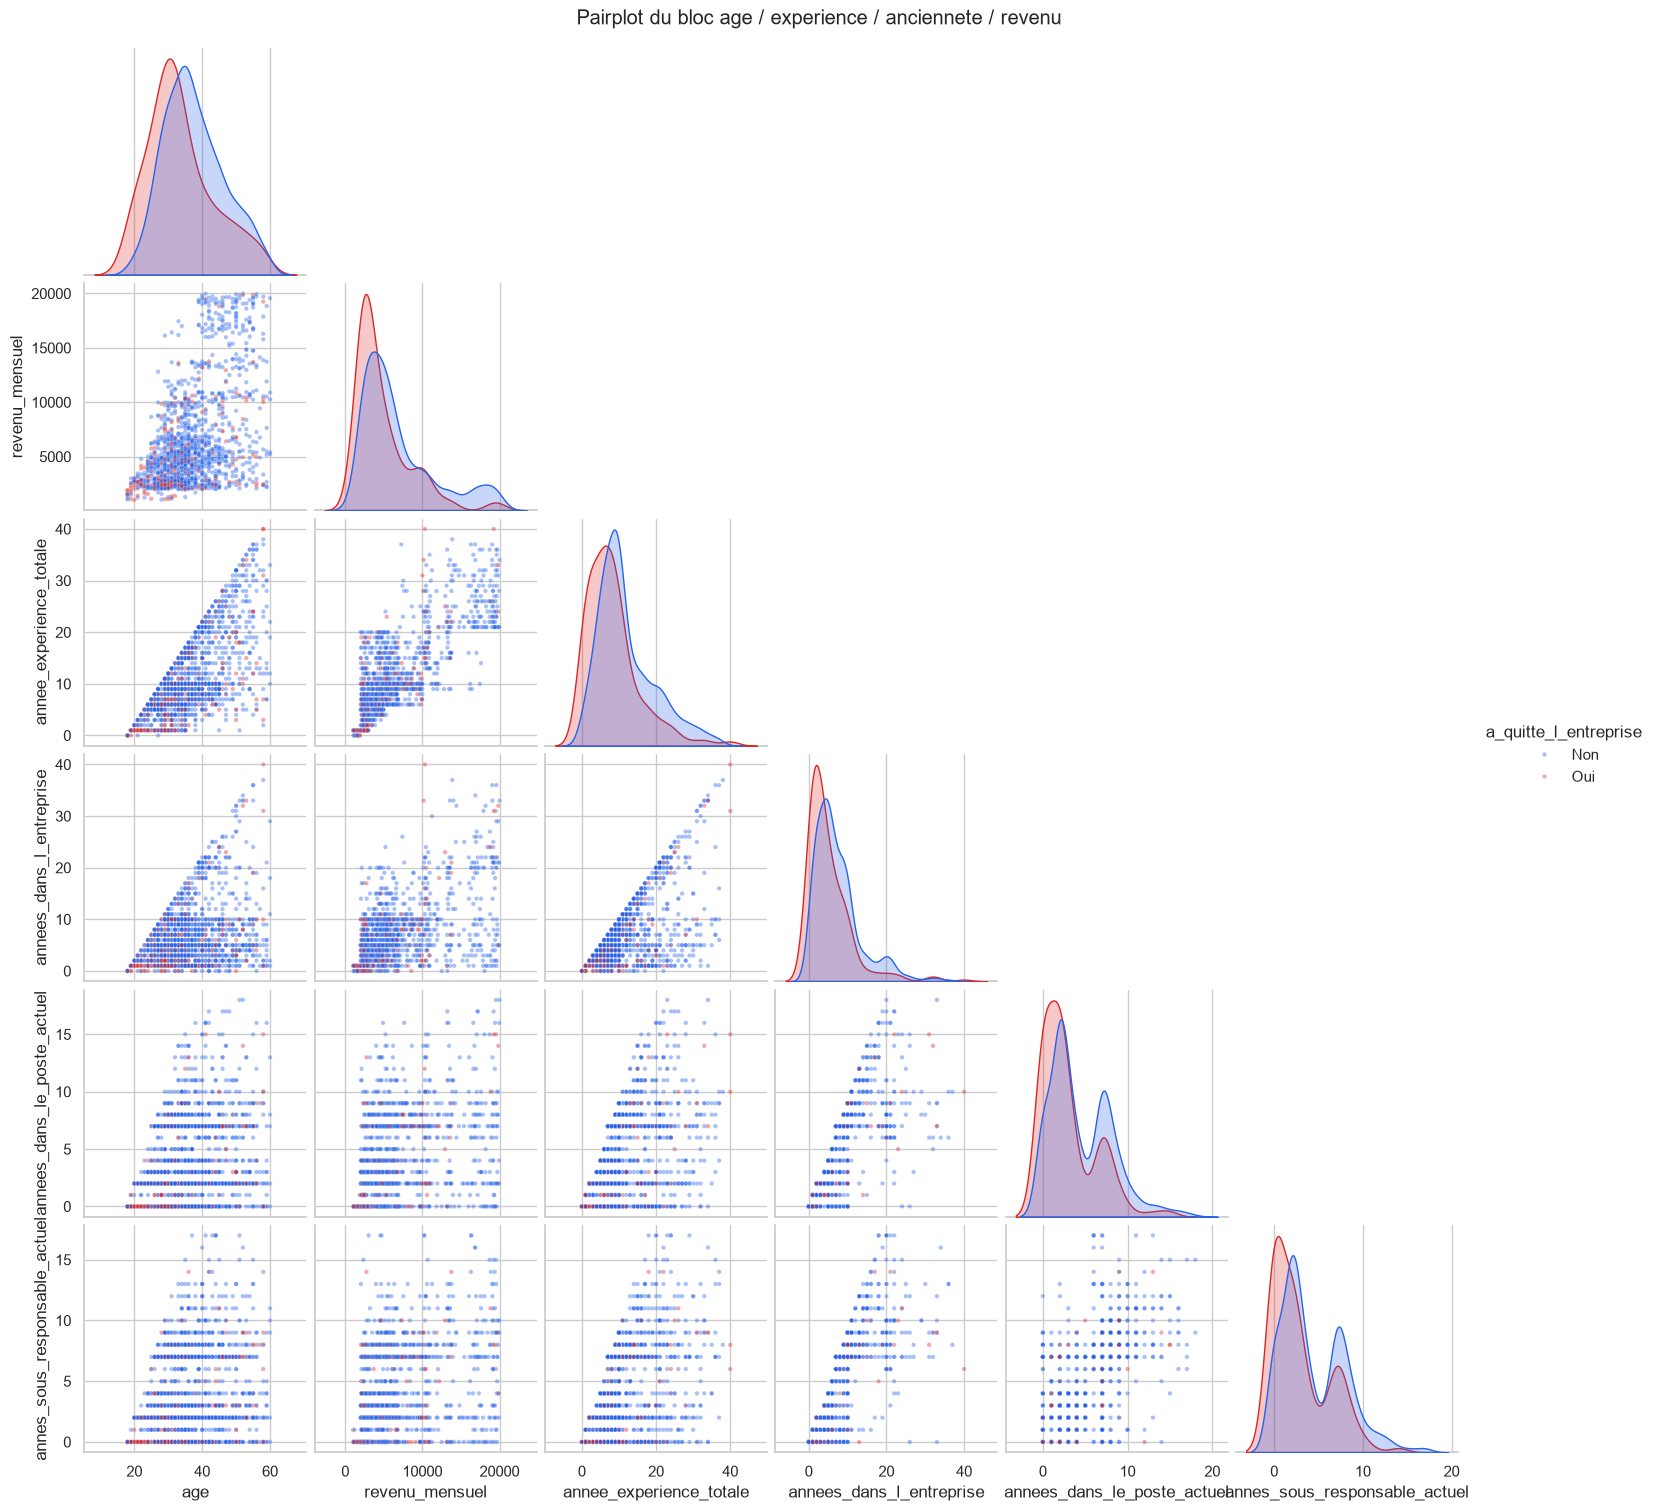

In [26]:
BLOC_PROFIL_ANCIENNETE = [
    "age",
    "revenu_mensuel",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "annes_sous_responsable_actuel",
]

grille = sns.pairplot(
    df[BLOC_PROFIL_ANCIENNETE + [config.CIBLE]],
    hue=config.CIBLE,
    hue_order=list(PALETTE_CIBLE),
    palette=PALETTE_CIBLE,
    corner=True,
    plot_kws={"alpha": 0.4, "s": 10},
    diag_kws={"common_norm": False},
)
grille.figure.suptitle(
    "Pairplot du bloc age / experience / anciennete / revenu", y=1.01
)
plt.show()

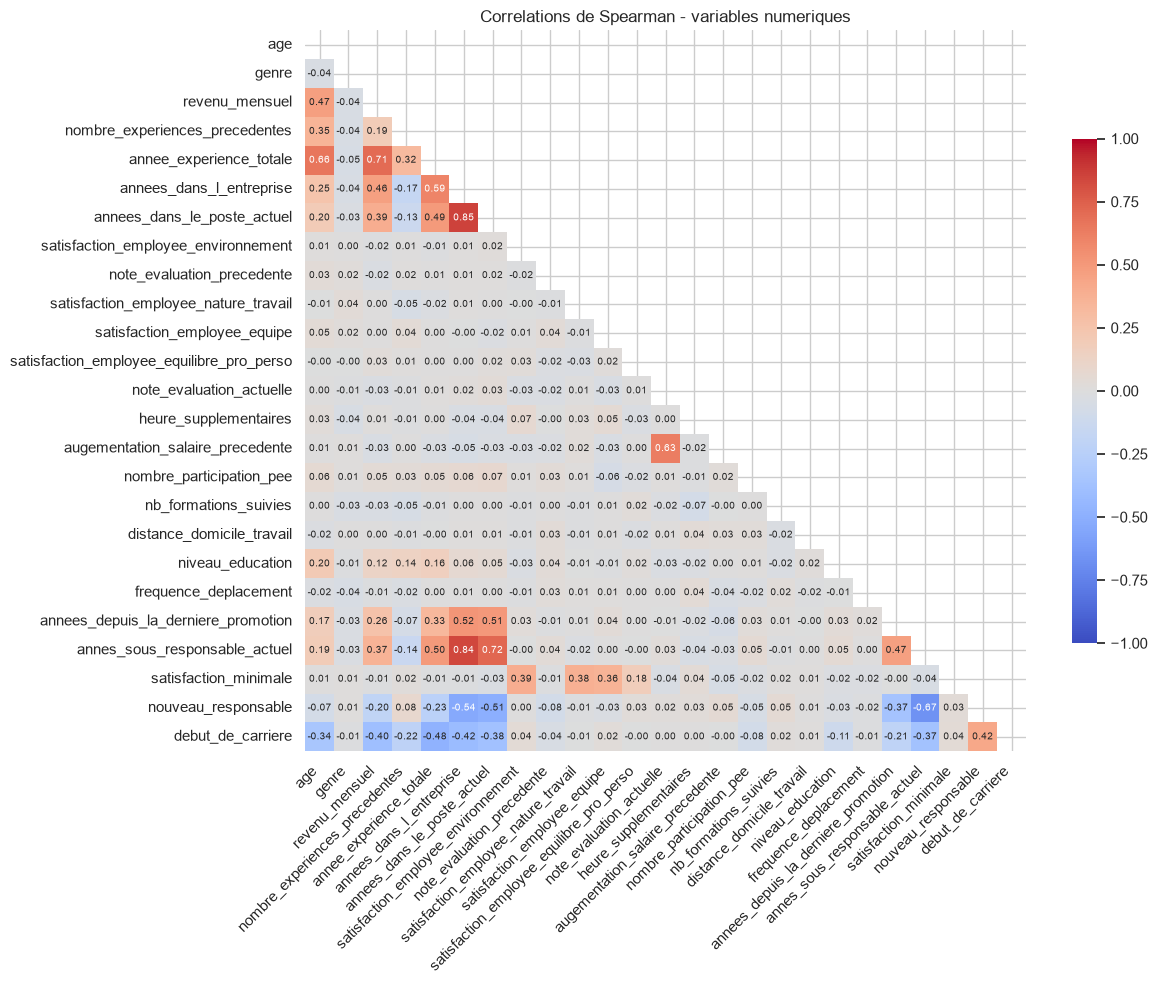

,variable_1,variable_2,spearman,pearson
0,annees_dans_le_poste_actuel,annees_dans_l_entreprise,0.854,0.759
1,annes_sous_responsable_actuel,annees_dans_l_entreprise,0.843,0.769
2,annes_sous_responsable_actuel,annees_dans_le_poste_actuel,0.725,0.714
3,annee_experience_totale,revenu_mensuel,0.710,0.773
4,nouveau_responsable,annes_sous_responsable_actuel,-0.672,-0.540
5,annee_experience_totale,age,0.657,0.680
6,augementation_salaire_precedente,note_evaluation_actuelle,0.629,0.774
7,annees_dans_l_entreprise,annee_experience_totale,0.594,0.628
8,nouveau_responsable,annees_dans_l_entreprise,-0.535,-0.376
9,annees_depuis_la_derniere_promotion,annees_dans_l_entreprise,0.520,0.618


In [27]:
matrice_spearman = features_numeriques.drop(columns=list(VARIABLES_REDONDANTES)).corr(
    method="spearman"
)
afficher_matrice_correlation(
    matrice_spearman, "Correlations de Spearman - variables numeriques"
)

# Comparaison directe Pearson / Spearman sur les paires les plus liees
comparaison_correlations = (
    lister_paires_correlees(matrice_spearman, 0.5)
    .assign(
        pearson=lambda t: [
            round(matrice_pearson.loc[a, b], 3)
            for a, b in zip(t["variable_1"], t["variable_2"])
        ]
    )
    .rename(columns={"correlation": "spearman"})
)
display(comparaison_correlations)

**Ma décision.** Le pairplot montre des relations croissantes mais dispersées et en éventail : l'écart entre collaborateurs augmente avec l'ancienneté. Sur le bloc des anciennetés, Spearman dépasse Pearson : 0,854 contre 0,759 entre `annees_dans_l_entreprise` et `annees_dans_le_poste_actuel`, 0,843 contre 0,769 avec `annes_sous_responsable_actuel`. Le lien est donc monotone mais pas linéaire, et Pearson le sous-estimait.

Le cas inverse existe aussi : entre `augementation_salaire_precedente` et `note_evaluation_actuelle`, Pearson (0,774) dépasse Spearman (0,629). La note actuelle ne prend que deux valeurs (3 ou 4) : les rangs comportent beaucoup d'ex aequo, ce qui fait baisser Spearman. Les deux variables restent sous le seuil de 0,8, je les garde.

Je conserve aussi les variables d'ancienneté. Chacune porte une information métier distincte (ancienneté dans l'entreprise, dans le poste, sous le même responsable), et aucune n'atteint le seuil de redondance linéaire. Ce lien reste à garder en tête pour la suite : ces variables se partageront l'importance dans le modèle, et je les lirai comme un bloc lors de l'interprétation.

**Les features créées.** `nouveau_responsable` est liée à -0,672 avec `annes_sous_responsable_actuel` au rang, ce qui est attendu puisqu'elle en est issue ; le lien reste sous le seuil de 0,8, et je la garde pour l'effet de seuil qu'elle porte. `debut_de_carriere` n'apparaît pas parmi les paires liées à plus de 0,5.

---
## 16. Construction de X et y

**Question.** Le DataFrame final peut-il être passé tel quel à la méthode `fit()` d'un modèle scikit-learn ?

**Méthode.** J'appelle `preparateur.transformer()` sur le DataFrame central complété des features créées au point 12 (`df_features`), en retirant les variables redondantes décidées au point 14. Je vérifie ensuite le résultat avec `check_X_y` de scikit-learn : c'est la fonction que les modèles appellent eux-mêmes au début de `fit()`. Elle refuse tout texte, toute valeur manquante et toute incohérence de taille entre `X` et `y`. Le contrôle est donc complet, sans rien entraîner.

In [28]:
X, y = preparateur.transformer(
    df_features, colonnes_a_retirer=list(VARIABLES_REDONDANTES)
)

# Controles de conformite du livrable de l'etape 2
assert X.index.equals(y.index), "X et y ne sont pas alignes"
assert X.select_dtypes(exclude="number").empty, (
    "Des colonnes non numeriques subsistent dans X"
)
assert not X.isna().any().any(), "Valeurs manquantes dans X"
assert set(y.unique()) == {0, 1}, "La cible doit etre codee en 0 / 1"
check_X_y(X, y)

print(f"X : {X.shape[0]} lignes x {X.shape[1]} features")
print(f"y : {y.shape[0]} valeurs, taux de depart {y.mean():.1%}")
display(X.head())

X : 1470 lignes x 46 features
y : 1470 valeurs, taux de depart 16.1%


,age,genre,revenu_mensuel,nombre_experiences_precedentes,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,nombre_participation_pee,nb_formations_suivies,distance_domicile_travail,niveau_education,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,satisfaction_minimale,nouveau_responsable,debut_de_carriere,departement_Commercial,departement_Consulting,departement_Ressources Humaines,poste_Assistant de Direction,poste_Cadre Commercial,poste_Consultant,poste_Directeur Technique,poste_Manager,poste_Représentant Commercial,poste_Ressources Humaines,poste_Senior Manager,poste_Tech Lead,statut_marital_Célibataire,statut_marital_Divorcé(e),statut_marital_Marié(e),domaine_etude_Autre,domaine_etude_Entrepreunariat,domaine_etude_Infra & Cloud,domaine_etude_Marketing,domaine_etude_Ressources Humaines,domaine_etude_Transformation Digitale
0,41,0,5993,8,8,6,4,2,3,4,1,1,3,1,11,0,0,1,2,1,0,5,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0
1,49,1,5130,1,10,10,7,3,2,2,4,3,4,0,23,1,3,8,1,2,1,7,2,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
2,37,1,2090,6,7,0,0,4,2,3,2,3,3,1,15,0,3,2,2,1,0,0,2,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
3,33,0,2909,1,8,8,7,4,3,3,3,3,3,1,11,0,3,3,4,2,3,0,3,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,27,1,3468,9,6,2,2,1,3,2,4,3,3,0,12,1,3,2,1,1,2,2,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1


**Point clé de l'étape.** `X` compte 1 470 lignes et 46 features entièrement numériques : 25 variables numériques (les 26 du point 13, moins `niveau_hierarchique_poste`) et 21 colonnes issues du one-hot des 4 nominales. `y` est une `pd.Series` binaire avec 16,1 % de départs, identique au taux mesuré après jointure. `check_X_y` passe sans erreur : le livrable de l'étape 2 est conforme.

Les échelles restent très différentes d'une colonne à l'autre (le revenu se compte en milliers, les colonnes one-hot valent 0 ou 1). C'est voulu : la mise à l'échelle sera ajustée à l'étape 3, dans un pipeline, sur le seul jeu d'entraînement.

---
## 17. Export

`X` et `y` sont les seuls fichiers que le notebook 02 relira. Le jeu consolidé et le dictionnaire des variables sont conservés pour la traçabilité.

In [29]:
df.to_parquet(config.FICHIER_CONSOLIDE, index=False)
dictionnaire_variables.to_csv(config.FICHIER_DICTIONNAIRE_VARIABLES, index=False)
X.to_parquet(config.FICHIER_X)
y.to_frame().to_parquet(config.FICHIER_Y)

print(f"Jeu consolide : {config.FICHIER_CONSOLIDE} ({df.shape[0]} x {df.shape[1]})")
print(f"Features X    : {config.FICHIER_X} ({X.shape[0]} x {X.shape[1]})")
print(f"Cible y       : {config.FICHIER_Y} ({y.shape[0]} valeurs)")

Jeu consolide : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh\data\interim\consolide.parquet (1470 x 29)
Features X    : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh\data\processed\X.parquet (1470 x 46)
Cible y       : C:\Users\Windows 11\Desktop\AI_Engineer\P4_Classification_rh\data\processed\y.parquet (1470 valeurs)
